In [63]:
# ----------------------------------------------------------------------------
# 0. Imports & global config
# ----------------------------------------------------------------------------
import os, joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


from pathlib import Path
from sklearn import set_config
from sklearn.impute import KNNImputer
from sklearn.preprocessing import FunctionTransformer
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import (
    StratifiedKFold, GridSearchCV,
    cross_validate, cross_val_predict,
    train_test_split
)
from sklearn.calibration import CalibratedClassifierCV, calibration_curve
from sklearn.metrics import (
    brier_score_loss, average_precision_score, roc_auc_score,
    precision_recall_curve, roc_curve,
    precision_score, recall_score, f1_score,
    confusion_matrix
)
from imblearn.pipeline import Pipeline as ImbPipeline
from imblearn.over_sampling import SMOTE
from xgboost import XGBClassifier

set_config(transform_output="pandas")

RANDOM_STATE = 42

RAW_SENSORS = [
    'Air_temperature_K',
    'Process_temperature_K',
    'Rotational_speed_rpm',
    'Torque_Nm',
    'Tool_wear_min'
]

TYPE_MAP = {
    'L': 0,
    'M': 1,
    'H': 2
}


# ----------------------------------------------------------------------------
# Global publication-grade figure style
# ----------------------------------------------------------------------------
FIG_DIR = Path('/content/figures')
FIG_DIR.mkdir(parents=True, exist_ok=True)

FIG_SIZE = (6, 4)
FIG_SIZE_WIDE = (12, 5)
FIG_SIZE_TALL = (6, 8)

CM_CMAP = 'Blues'
MISSING_CMAP = 'Blues'
CORR_CMAP = 'vlag'

sns.set_theme(
    context='notebook',
    style='whitegrid',
    palette='colorblind'
)

plt.rcParams.update({
    'figure.figsize': FIG_SIZE,
    'font.size': 10,
    'axes.titlesize': 13,
    'axes.labelsize': 11,
    'xtick.labelsize': 10,
    'ytick.labelsize': 10,
    'legend.fontsize': 10,
    'axes.grid': True,
    'grid.alpha': 0.3,
    'axes.spines.top': False,
    'axes.spines.right': False,
    'figure.dpi': 100,
    'savefig.dpi': 300,
    'savefig.bbox': 'tight',
    'savefig.pad_inches': 0.1,
    'pdf.fonttype': 42,
    'ps.fonttype': 42
})


def save_figure(fig, filename):
    """Save figure as PNG 300dpi + PDF + SVG."""

    fig.tight_layout()

    fig.savefig(
        FIG_DIR / f'{filename}.png',
        dpi=300
    )

    fig.savefig(
        FIG_DIR / f'{filename}.pdf'
    )

    fig.savefig(
        FIG_DIR / f'{filename}.svg'
    )

In [64]:
# ============================================================================
# 1. Dataset Loading & Structural Preprocessing (No Imputation Here)
# ============================================================================
def load_pmdi(path):
    df = pd.read_csv(path)
    df['Date'] = pd.to_datetime(df['Date'], format='%d/%m/%Y %H:%M')
    df = df.sort_values(['System', 'Date']).reset_index(drop=True)
    df.columns = (df.columns.str.replace('(', '', regex=False)
                            .str.replace(')', '', regex=False)
                            .str.replace(' ', '_', regex=False))
    df['Type'] = df['Type'].map(TYPE_MAP)
    return df

# ----------------------------------------------------------------------------
# Execute loading and basic inspection
# ----------------------------------------------------------------------------
df = load_pmdi('/content/AI4I-PMDI.csv')

print("Dataset shape:", df.shape)
print("\nColumns:")
print(df.columns.tolist())

print("\nFirst 5 rows:")
display(df.head())

Dataset shape: (10000, 12)

Columns:
['UDI', 'Date', 'System', 'Control', 'Product_ID', 'Type', 'Air_temperature_K', 'Process_temperature_K', 'Rotational_speed_rpm', 'Torque_Nm', 'Tool_wear_min', 'Diagnostic']

First 5 rows:


,UDI,Date,System,Control,Product_ID,Type,Air_temperature_K,Process_temperature_K,Rotational_speed_rpm,Torque_Nm,Tool_wear_min,Diagnostic
0,2,2014-04-12 16:09:00,0,A,L47181,0,298.2,308.7,1408.0,NaN,NaN,No failure
1,3,2014-04-13 01:13:00,0,A,L47182,0,298.1,308.5,1498.0,NaN,NaN,No failure
2,1,2014-04-15 11:56:00,0,C,M14860,1,NaN,NaN,NaN,42.8,0.0,No failure
3,8,2014-07-22 01:24:00,0,B,L47187,0,NaN,NaN,1527.0,40.2,NaN,No failure
4,5,2014-07-22 01:31:00,0,C,L47184,0,NaN,NaN,NaN,40.0,9.0,No failure


In [65]:
# ----------------------------------------------------------------------------
# 1.1 Exploratory Data Analysis: Diagnostics, controls, and missingness patterns
# ----------------------------------------------------------------------------

print("Diagnostic distribution:")
print(df['Diagnostic'].value_counts(dropna=False))

print("\nControl distribution:")
print(df['Control'].value_counts(dropna=False))

print("\nMissing values per column:")
print(df.isna().sum().sort_values(ascending=False))

sensor_cols = [
    'Air_temperature_K',
    'Process_temperature_K',
    'Rotational_speed_rpm',
    'Torque_Nm',
    'Tool_wear_min'
]

missing_by_control = (
    df.groupby('Control')[sensor_cols]
      .apply(lambda x: x.isna().mean() * 100)
)

print("Missing values (%) by Control:")
display(missing_by_control.round(2))

Diagnostic distribution:
Diagnostic
No failure                  9652
Heat Dissipation Failure     106
Overstrain Failure            98
Power Failure                 83
Tool Wear Failure             42
Random Failures               19
Name: count, dtype: int64

Control distribution:
Control
A    3437
C    3321
B    3242
Name: count, dtype: int64

Missing values per column:
Tool_wear_min            6679
Process_temperature_K    6563
Air_temperature_K        6563
Torque_Nm                3437
Rotational_speed_rpm     3321
System                      0
Date                        0
UDI                         0
Control                     0
Type                        0
Product_ID                  0
Diagnostic                  0
dtype: int64
Missing values (%) by Control:


,Air_temperature_K,Process_temperature_K,Rotational_speed_rpm,Torque_Nm,Tool_wear_min
Control,,,,,
A,0.0,0.0,0.0,100.0,100.0
B,100.0,100.0,0.0,0.0,100.0
C,100.0,100.0,100.0,0.0,0.0


In [66]:
# ----------------------------------------------------------------------------
# 2. Feature Engineering & Leakage-Safe Pipeline Construction
# ----------------------------------------------------------------------------
def engineer_features(X: pd.DataFrame) -> pd.DataFrame:
    X = X.copy()
    X['Power_W'] = X['Torque_Nm'] * (X['Rotational_speed_rpm'] * 2 * np.pi / 60)
    X['Temp_diff_K'] = X['Process_temperature_K'] - X['Air_temperature_K']
    return X

FEATURE_ENGINEER = FunctionTransformer(engineer_features)


def build_pipeline(clf, use_smote=False) -> ImbPipeline:
    """
    Leakage-safe pipeline.

    KNN imputation και feature engineering γίνονται
    μέσα σε κάθε training fold.

    Το SMOTE παραμένει διαθέσιμο μόνο για πειραματική
    σύγκριση, αλλά δεν χρησιμοποιείται στο τελικό
    Agent 1 pipeline.
    """

    steps = [
        ('imputer', KNNImputer(n_neighbors=5)),
        ('features', FEATURE_ENGINEER),
    ]

    if use_smote:
        steps.append(
            ('smote', SMOTE(random_state=RANDOM_STATE))
        )

    steps.append(
        ('clf', clf)
    )

    return ImbPipeline(steps=steps)


In [67]:
# ============================================================================
# 3. Target Definition (Excluding Random Failures for Agent 1 Training)
# ============================================================================
def define_target(df):
    """
    Binary target για τον Agent 1.

    0 = No Failure
    1 = Predictable Failure

    Τα Random Failures εξαιρούνται από το supervised training.
    """

    # Κρατάμε όλες τις γραμμές εκτός από Random Failures
    model_mask = df['Diagnostic'] != 'Random Failures'

    df_model = df.loc[model_mask].copy()

    # Input features
    X = df_model[['Type'] + RAW_SENSORS].copy()

    # Binary target
    y = (df_model['Diagnostic'] != 'No failure').astype(int)

    return X, y

# ----------------------------------------------------------------------------
# Execute target definition and verify sizes/distributions
# ----------------------------------------------------------------------------
X, y = define_target(df)

print("Dataset size after RNF exclusion:", len(y))
print("\nBinary target distribution:")
print(y.value_counts())

print("\nBinary target percentages:")
print((y.value_counts(normalize=True) * 100).round(2))

Dataset size after RNF exclusion: 9981

Binary target distribution:
Diagnostic
0    9652
1     329
Name: count, dtype: int64

Binary target percentages:
Diagnostic
0    96.7
1     3.3
Name: proportion, dtype: float64


In [68]:
# ============================================================================
# 4. Class Imbalance Strategy Comparison (Stratified CV Evaluation)
# ============================================================================

from sklearn.model_selection import cross_validate


def compare_imbalance_strategies(X, y):
    """
    Συγκρίνει τέσσερις στρατηγικές class imbalance
    με ακριβώς το ίδιο 5-fold stratified CV.
    """

    cv = StratifiedKFold(
        n_splits=5,
        shuffle=True,
        random_state=RANDOM_STATE
    )

    # Αρχικός λόγος negatives / positives
    spw = (y == 0).sum() / (y == 1).sum()

    print(f"scale_pos_weight = {spw:.2f}")

    strategies = {

        # 1. Χωρίς καμία ειδική διόρθωση
        'XGBoost plain': (
            XGBClassifier(
                scale_pos_weight=1.0,
                eval_metric='logloss',
                random_state=RANDOM_STATE
            ),
            False
        ),

        # 2. Μόνο class weighting
        'XGBoost weighted': (
            XGBClassifier(
                scale_pos_weight=spw,
                eval_metric='logloss',
                random_state=RANDOM_STATE
            ),
            False
        ),

        # 3. Μόνο SMOTE
        'XGBoost + SMOTE': (
            XGBClassifier(
                scale_pos_weight=1.0,
                eval_metric='logloss',
                random_state=RANDOM_STATE
            ),
            True
        ),

        # 4. SMOTE + weighting
        'XGBoost + SMOTE + weight': (
            XGBClassifier(
                scale_pos_weight=spw,
                eval_metric='logloss',
                random_state=RANDOM_STATE
            ),
            True
        )
    }

    scoring = [
        'precision',
        'recall',
        'f1',
        'roc_auc',
        'average_precision'
    ]

    results = []

    for name, (clf, use_smote) in strategies.items():

        print(f"\nRunning: {name}")

        scores = cross_validate(
            build_pipeline(
                clf,
                use_smote=use_smote
            ),
            X,
            y,
            cv=cv,
            scoring=scoring,
            n_jobs=-1
        )

        results.append({
            'Strategy': name,
            'Precision': scores['test_precision'].mean(),
            'Recall': scores['test_recall'].mean(),
            'F1': scores['test_f1'].mean(),
            'ROC-AUC': scores['test_roc_auc'].mean(),
            'Average Precision': scores['test_average_precision'].mean()
        })

    results_df = pd.DataFrame(results)

    return results_df

# ----------------------------------------------------------------------------
# Execute imbalance strategy comparison
# ----------------------------------------------------------------------------
imbalance_results = compare_imbalance_strategies(X, y)

display(
    imbalance_results.round(4)
)

scale_pos_weight = 29.34

Running: XGBoost plain

Running: XGBoost weighted

Running: XGBoost + SMOTE

Running: XGBoost + SMOTE + weight


,Strategy,Precision,Recall,F1,ROC-AUC,Average Precision
0,XGBoost plain,0.8959,0.8298,0.8612,0.9956,0.9316
1,XGBoost weighted,0.8576,0.8631,0.8595,0.9937,0.9300
2,XGBoost + SMOTE,0.8362,0.8662,0.8505,0.9940,0.9267
3,XGBoost + SMOTE + weight,0.7548,0.8966,0.8195,0.9919,0.9188


In [70]:
# ----------------------------------------------------------------------------
# 5. Baseline Model Comparison (LogReg vs Random Forest vs XGBoost)
# ----------------------------------------------------------------------------

def compare_models(X, y, spw):

    cv = StratifiedKFold(
        n_splits=5,
        shuffle=True,
        random_state=RANDOM_STATE
    )

    models = {
        'Logistic Regression': LogisticRegression(
            max_iter=1000,
            class_weight='balanced'
        ),

        'Random Forest': RandomForestClassifier(
            n_estimators=300,
            class_weight='balanced',
            random_state=RANDOM_STATE
        ),

        'XGBoost': XGBClassifier(
            scale_pos_weight=spw,
            eval_metric='logloss',
            random_state=RANDOM_STATE
        )
    }

    scoring = [
        'precision',
        'recall',
        'f1',
        'roc_auc',
        'average_precision'
    ]

    results = []

    for name, model in models.items():

        print(f"Running: {name}")

        scores = cross_validate(
            build_pipeline(model, use_smote=False),
            X,
            y,
            cv=cv,
            scoring=scoring,
            n_jobs=-1
        )

        results.append({
            'Model': name,
            'Precision': scores['test_precision'].mean(),
            'Recall': scores['test_recall'].mean(),
            'F1': scores['test_f1'].mean(),
            'ROC-AUC': scores['test_roc_auc'].mean(),
            'Average Precision': scores['test_average_precision'].mean()
        })

    return pd.DataFrame(results)



# ----------------------------------------------------------------------------
# Run baseline model comparison
# ----------------------------------------------------------------------------

spw = (y == 0).sum() / (y == 1).sum()

print(f"scale_pos_weight = {spw:.4f}")

model_results = compare_models(X, y, spw)

display(model_results.round(4))

scale_pos_weight = 29.3374
Running: Logistic Regression
Running: Random Forest
Running: XGBoost


,Model,Precision,Recall,F1,ROC-AUC,Average Precision
0,Logistic Regression,0.1789,0.8906,0.2979,0.9461,0.4509
1,Random Forest,0.9467,0.7536,0.8388,0.9932,0.9316
2,XGBoost,0.8576,0.8631,0.8595,0.9937,0.9300


In [71]:
# ----------------------------------------------------------------------------
# 6. Rigorous Nested Cross-Validation & Hyperparameter Optimization
# ----------------------------------------------------------------------------
PARAM_GRID = {
    'clf__max_depth': [3, 5],
    'clf__n_estimators': [100, 200],
    'clf__learning_rate': [0.05, 0.1],
}
SCORING = ['precision', 'recall', 'f1', 'roc_auc', 'average_precision']


def nested_cv_evaluate(X, y, spw):
    outer = StratifiedKFold(
        5,
        shuffle=True,
        random_state=RANDOM_STATE
    )

    inner = StratifiedKFold(
        3,
        shuffle=True,
        random_state=RANDOM_STATE
    )

    base = XGBClassifier(
        scale_pos_weight=spw,
        eval_metric='logloss',
        random_state=RANDOM_STATE
    )

    search = GridSearchCV(
        build_pipeline(base, use_smote=False),
        PARAM_GRID,
        scoring='average_precision',
        cv=inner,
        n_jobs=-1
    )

    res = cross_validate(
        search,
        X,
        y,
        cv=outer,
        scoring=SCORING,
        n_jobs=-1
    )

    print("=== Nested-CV (τίμια γενίκευση) ===")

    for m in SCORING:
        s = res[f'test_{m}']
        print(
            f"  {m:<18}: "
            f"{s.mean():.4f} ± {s.std():.4f}"
        )

    return res


def collect_fold_curves(pipe, X, y):
    """Per-fold ROC & PR curves — για SOTA καμπύλες με σκιασμένη ζώνη (CI band)."""
    cv = StratifiedKFold(5, shuffle=True, random_state=RANDOM_STATE)
    fold_data = []
    for tr, te in cv.split(X, y):
        pipe.fit(X.iloc[tr], y.iloc[tr])
        p = pipe.predict_proba(X.iloc[te])[:, 1]
        fpr, tpr, _ = roc_curve(y.iloc[te], p)
        prec, rec, _ = precision_recall_curve(y.iloc[te], p)
        fold_data.append({'fpr': fpr, 'tpr': tpr, 'prec': prec, 'rec': rec,
                          'auc': roc_auc_score(y.iloc[te], p),
                          'ap': average_precision_score(y.iloc[te], p)})
    return fold_data   # -> figures: ROC & PR με mean ± std band



In [72]:
# ----------------------------------------------------------------------------
# 6.1 Execute Nested Cross-Validation evaluation
# ----------------------------------------------------------------------------

spw = (y == 0).sum() / (y == 1).sum()

nested_res = nested_cv_evaluate(
    X=X,
    y=y,
    spw=spw
)

=== Nested-CV (τίμια γενίκευση) ===
  precision         : 0.7617 ± 0.0822
  recall            : 0.8996 ± 0.0267
  f1                : 0.8220 ± 0.0413
  roc_auc           : 0.9947 ± 0.0032
  average_precision : 0.9242 ± 0.0297


In [73]:
# ----------------------------------------------------------------------------
# 7. Final Hyperparameter Optimization on Full Dataset & Curve Collection
# ----------------------------------------------------------------------------

# 1. Εκτέλεση Grid Search στο σύνολο των δεδομένων
spw = (y == 0).sum() / (y == 1).sum()

final_search = GridSearchCV(
    estimator=build_pipeline(
        XGBClassifier(
            scale_pos_weight=spw,
            eval_metric='logloss',
            random_state=RANDOM_STATE
        ),
        use_smote=False
    ),
    param_grid=PARAM_GRID,
    scoring='average_precision',
    cv=StratifiedKFold(
        n_splits=5,
        shuffle=True,
        random_state=RANDOM_STATE
    ),
    n_jobs=-1
)

final_search.fit(X, y)

# 2. Αυτόματη εξαγωγή βέλτιστων παραμέτρων (χωρίς hardcoding)
best = {
    k.replace('clf__', ''): v
    for k, v in final_search.best_params_.items()
}

print("Best hyperparameters found:", best)
print(f"Best CV Average Precision: {final_search.best_score_:.4f}\n")

# 3. Κατασκευή τελικού pipeline και συλλογή fold curves για τα SOTA plots
best_model = XGBClassifier(
    scale_pos_weight=spw,
    eval_metric='logloss',
    random_state=RANDOM_STATE,
    **best
)

best_pipe = build_pipeline(
    best_model,
    use_smote=False
)

fold_data = collect_fold_curves(
    best_pipe,
    X,
    y
)

print(f"Successfully collected data from {len(fold_data)} folds.")
for i, fold in enumerate(fold_data, start=1):
    print(f"  Fold {i}: ROC-AUC={fold['auc']:.4f}, AP={fold['ap']:.4f}")



Best hyperparameters found: {'learning_rate': 0.1, 'max_depth': 5, 'n_estimators': 200}
Best CV Average Precision: 0.9319

Successfully collected data from 5 folds.
  Fold 1: ROC-AUC=0.9888, AP=0.9458
  Fold 2: ROC-AUC=0.9947, AP=0.8915
  Fold 3: ROC-AUC=0.9976, AP=0.9482
  Fold 4: ROC-AUC=0.9970, AP=0.9520
  Fold 5: ROC-AUC=0.9958, AP=0.9218


In [74]:
# ----------------------------------------------------------------------------
# 7.1 Store best hyperparameters
# ----------------------------------------------------------------------------

best = {
    'learning_rate': 0.1,
    'max_depth': 5,
    'n_estimators': 200
}

print("Best hyperparameters stored:")
print(best)

Best hyperparameters stored:
{'learning_rate': 0.1, 'max_depth': 5, 'n_estimators': 200}


In [75]:
# ----------------------------------------------------------------------------
# 7.2 Build best model using stored hyperparameters & collect fold curves
# ----------------------------------------------------------------------------

best_model = XGBClassifier(
    scale_pos_weight=spw,
    eval_metric='logloss',
    random_state=RANDOM_STATE,
    **best
)

best_pipe = build_pipeline(
    best_model,
    use_smote=False
)

fold_data = collect_fold_curves(
    best_pipe,
    X,
    y
)

print(f"Collected data from {len(fold_data)} folds.")

for i, fold in enumerate(fold_data, start=1):
    print(
        f"Fold {i}: "
        f"ROC-AUC={fold['auc']:.4f}, "
        f"AP={fold['ap']:.4f}"
    )

Collected data from 5 folds.
Fold 1: ROC-AUC=0.9888, AP=0.9458
Fold 2: ROC-AUC=0.9947, AP=0.8915
Fold 3: ROC-AUC=0.9976, AP=0.9482
Fold 4: ROC-AUC=0.9970, AP=0.9520
Fold 5: ROC-AUC=0.9958, AP=0.9218


In [76]:
# ----------------------------------------------------------------------------
# 8. Probability Calibration (Uncalibrated vs Sigmoid vs Isotonic)
# ----------------------------------------------------------------------------
def compute_ece(y_true, y_prob, n_bins=10):
    edges = np.linspace(0, 1, n_bins + 1); ece = 0.0
    for i in range(n_bins):
        m = (y_prob >= edges[i]) & (y_prob < edges[i + 1])
        if m.sum():
            ece += (m.sum() / len(y_prob)) * abs(y_prob[m].mean() - y_true[m].mean())
    return ece


def oof_probs(X, y, best, spw):
    """
    Συγκρίνει:
    1. Uncalibrated probabilities
    2. Sigmoid calibration
    3. Isotonic calibration

    Όλα υπολογίζονται με out-of-fold predictions,

    """

    cv = StratifiedKFold(
        n_splits=5,
        shuffle=True,
        random_state=RANDOM_STATE
    )

    clf = XGBClassifier(
        scale_pos_weight=spw,
        eval_metric='logloss',
        random_state=RANDOM_STATE,
        **best
    )


    # 1. Uncalibrated probabilities
    # ---------------------------------------------------------
    p_uncal = cross_val_predict(
        build_pipeline(clf, use_smote=False),
        X,
        y,
        cv=cv,
        method='predict_proba',
        n_jobs=-1
    )[:, 1]


    # 2. Sigmoid calibration
    # ---------------------------------------------------------
    sigmoid_cal = CalibratedClassifierCV(
        build_pipeline(clf, use_smote=False),
        method='sigmoid',
        cv=3
    )

    p_sigmoid = cross_val_predict(
        sigmoid_cal,
        X,
        y,
        cv=cv,
        method='predict_proba',
        n_jobs=-1
    )[:, 1]


    # 3. Isotonic calibration
    # ---------------------------------------------------------
    isotonic_cal = CalibratedClassifierCV(
        build_pipeline(clf, use_smote=False),
        method='isotonic',
        cv=3
    )

    p_isotonic = cross_val_predict(
        isotonic_cal,
        X,
        y,
        cv=cv,
        method='predict_proba',
        n_jobs=-1
    )[:, 1]

    # ---------------------------------------------------------
    # Metrics
    # ---------------------------------------------------------
    results = pd.DataFrame({
        'Method': [
            'Uncalibrated',
            'Sigmoid',
            'Isotonic'
        ],
        'Brier': [
            brier_score_loss(y, p_uncal),
            brier_score_loss(y, p_sigmoid),
            brier_score_loss(y, p_isotonic)
        ],
        'ECE': [
            compute_ece(y.values, p_uncal),
            compute_ece(y.values, p_sigmoid),
            compute_ece(y.values, p_isotonic)
        ]
    })

    print("=== Calibration comparison ===")
    display(results.round(4))

    return p_uncal, p_sigmoid, p_isotonic, results

In [77]:
# ----------------------------------------------------------------------------
# 8.1 Execute calibration comparison and select Isotonic method
# ----------------------------------------------------------------------------

p_uncal, p_sigmoid, p_isotonic, calibration_results = oof_probs(
    X=X,
    y=y,
    best=best,
    spw=spw
)

p_cal = p_isotonic

CALIBRATION_METHOD = 'isotonic'

print(f"Selected calibration method: {CALIBRATION_METHOD}")

=== Calibration comparison ===


,Method,Brier,ECE
0,Uncalibrated,0.0085,0.0068
1,Sigmoid,0.0077,0.0090
2,Isotonic,0.0066,0.0045


Selected calibration method: isotonic


In [78]:
# ----------------------------------------------------------------------------
# 9. Cost-Sensitive Decision Analysis & Optimal Threshold Selection
# ----------------------------------------------------------------------------
def cost_curve(y_true, y_prob, c_fn=10.0, c_fp=1.0):
    ts = np.linspace(0.01, 0.99, 99)
    costs = np.array([
        c_fn * ((y_true == 1) & (y_prob < t)).sum() +
        c_fp * ((y_true == 0) & (y_prob >= t)).sum() for t in ts])
    t_star = float(ts[int(costs.argmin())])
    print(f"Cost-optimal threshold (C_FN={c_fn}, C_FP={c_fp}): {t_star:.2f}")
    return ts, costs, t_star   # -> figure: expected cost vs threshold, mark t*


def cost_sensitivity(y_true, y_prob, ratios=(2, 5, 10, 20, 50)):
    """t* ως συνάρτηση του λόγου C_FN/C_FP — για SOTA sensitivity figure."""
    out = {}
    for r in ratios:
        _, _, t = cost_curve(y_true, y_prob, c_fn=r, c_fp=1.0)
        out[r] = t
    return out   # -> figure: t* vs cost-ratio


# Execute cost analysis and find optimal decision threshold
# ----------------------------------------------------------------------------
C_FN = 10.0
C_FP = 1.0

ts, costs, t_star = cost_curve(
    y_true=y.values,
    y_prob=p_cal,
    c_fn=C_FN,
    c_fp=C_FP
)

print(f"\nSelected threshold: {t_star:.2f}")

Cost-optimal threshold (C_FN=10.0, C_FP=1.0): 0.14

Selected threshold: 0.14


In [79]:
# ----------------------------------------------------------------------------
# 9.1 Evaluate performance at selected threshold
# ----------------------------------------------------------------------------

# 1. Αξιολόγηση απόδοσης στο βέλτιστο threshold (t_star)
y_pred_cost = (p_cal >= t_star).astype(int)

precision_t = precision_score(y, y_pred_cost)
recall_t = recall_score(y, y_pred_cost)
f1_t = f1_score(y, y_pred_cost)

fp = ((y == 0) & (y_pred_cost == 1)).sum()
fn = ((y == 1) & (y_pred_cost == 0)).sum()
tp = ((y == 1) & (y_pred_cost == 1)).sum()
tn = ((y == 0) & (y_pred_cost == 0)).sum()

print(f"Threshold: {t_star:.2f}")
print(f"Precision: {precision_t:.4f}")
print(f"Recall:    {recall_t:.4f}")
print(f"F1:        {f1_t:.4f}")

print("\nConfusion counts:")
print(f"TP = {tp}")
print(f"FP = {fp}")
print(f"TN = {tn}")
print(f"FN = {fn}")

# 2. Ανάλυση ευαισθησίας κόστους (Cost Sensitivity Analysis)
cost_ratios = [2, 5, 10, 20, 50]

sens = cost_sensitivity(
    y_true=y.values,
    y_prob=p_cal,
    ratios=cost_ratios
)

print("\nCost sensitivity:")
for ratio, threshold in sens.items():
    print(
        f"C_FN / C_FP = {ratio:>2}  "
        f"-> optimal threshold = {threshold:.2f}"
    )


Threshold: 0.14
Precision: 0.6574
Recall:    0.9331
F1:        0.7714

Confusion counts:
TP = 307
FP = 160
TN = 9492
FN = 22
Cost-optimal threshold (C_FN=2, C_FP=1.0): 0.34
Cost-optimal threshold (C_FN=5, C_FP=1.0): 0.24
Cost-optimal threshold (C_FN=10, C_FP=1.0): 0.14
Cost-optimal threshold (C_FN=20, C_FP=1.0): 0.08
Cost-optimal threshold (C_FN=50, C_FP=1.0): 0.02

Cost sensitivity:
C_FN / C_FP =  2  -> optimal threshold = 0.34
C_FN / C_FP =  5  -> optimal threshold = 0.24
C_FN / C_FP = 10  -> optimal threshold = 0.14
C_FN / C_FP = 20  -> optimal threshold = 0.08
C_FN / C_FP = 50  -> optimal threshold = 0.02


In [80]:
# ----------------------------------------------------------------------------
# 9.2 Detailed Cost-Sensitivity Metrics Table Generation
# ----------------------------------------------------------------------------

sensitivity_rows = []

for ratio in cost_ratios:

    _, _, threshold = cost_curve(
        y_true=y.values,
        y_prob=p_cal,
        c_fn=ratio,
        c_fp=1.0
    )

    y_pred = (p_cal >= threshold).astype(int)

    tp = ((y == 1) & (y_pred == 1)).sum()
    fp = ((y == 0) & (y_pred == 1)).sum()
    tn = ((y == 0) & (y_pred == 0)).sum()
    fn = ((y == 1) & (y_pred == 0)).sum()

    sensitivity_rows.append({
        'C_FN/C_FP': ratio,
        'Threshold': threshold,
        'Precision': precision_score(y, y_pred),
        'Recall': recall_score(y, y_pred),
        'F1': f1_score(y, y_pred),
        'FP': fp,
        'FN': fn
    })

cost_sensitivity_df = pd.DataFrame(sensitivity_rows)

display(cost_sensitivity_df.round(4))

Cost-optimal threshold (C_FN=2, C_FP=1.0): 0.34
Cost-optimal threshold (C_FN=5, C_FP=1.0): 0.24
Cost-optimal threshold (C_FN=10, C_FP=1.0): 0.14
Cost-optimal threshold (C_FN=20, C_FP=1.0): 0.08
Cost-optimal threshold (C_FN=50, C_FP=1.0): 0.02


,C_FN/C_FP,Threshold,Precision,Recall,F1,FP,FN
0,2,0.34,0.8871,0.8602,0.8735,36,46
1,5,0.24,0.8017,0.8845,0.8410,72,38
2,10,0.14,0.6574,0.9331,0.7714,160,22
3,20,0.08,0.5420,0.9605,0.6930,267,13
4,50,0.02,0.3602,0.9909,0.5284,579,3


In [81]:
# ----------------------------------------------------------------------------
# 10 Conformal Prediction Functions (LAC Score & Coverage Sweep)
# ----------------------------------------------------------------------------
def conformal_qhat(y_true, p1, alpha=0.10):
    """
    Υπολογίζει το conformal quantile (qhat) βάσει του nonconformity score.
    """
    p = np.column_stack([1 - p1, p1])
    scores = 1 - p[np.arange(len(y_true)), y_true.values]
    n = len(scores)
    qhat = float(np.quantile(scores, min(np.ceil((n + 1) * (1 - alpha)) / n, 1.0),
                             method='higher'))
    print(f"Conformal qhat (alpha={alpha}): {qhat:.4f}")
    return qhat, scores   # scores -> figure: nonconformity histogram + qhat line

def conformal_sweep(
    y_true,
    p1,
    alphas=np.linspace(0.01, 0.30, 15)
):
    """
    Ελέγχει την conformal συμπεριφορά για διαφορετικά alpha.

    Επιστρέφει:
    - empirical coverage
    - mean prediction-set size
    - empty-set rate
    - ambiguous-set rate ({0,1})
    - total uncertainty rate
    """

    p = np.column_stack([1 - p1, p1])
    n = len(y_true)

    coverage = []
    mean_size = []
    empty_rate = []
    ambiguous_rate = []
    uncertainty_rate = []

    for alpha in alphas:

        # Nonconformity score της πραγματικής κλάσης
        scores = (
            1
            - p[np.arange(n), y_true.values]
        )

        # Finite-sample conformal quantile
        qhat = np.quantile(
            scores,
            min(
                np.ceil((n + 1) * (1 - alpha)) / n,
                1.0
            ),
            method='higher'
        )

        # Prediction sets
        sets = (1 - p) <= qhat

        set_sizes = sets.sum(axis=1)

        # Empirical coverage
        covered = (
            sets[
                np.arange(n),
                y_true.values
            ].mean()
        )

        coverage.append(covered)

        # Average number of classes in the set
        mean_size.append(
            set_sizes.mean()
        )

        # {} : καμία κλάση
        empty_rate.append(
            (set_sizes == 0).mean()
        )

        # {0,1} : και οι δύο κλάσεις
        ambiguous_rate.append(
            (set_sizes == 2).mean()
        )

        # Οτιδήποτε δεν είναι singleton
        uncertainty_rate.append(
            (set_sizes != 1).mean()
        )

    return (
        alphas,
        np.array(coverage),
        np.array(mean_size),
        np.array(empty_rate),
        np.array(ambiguous_rate),
        np.array(uncertainty_rate)
    )

In [82]:
# ----------------------------------------------------------------------------
# 10.1 Execution of Conformal Uncertainty & Coverage Sweep
# ----------------------------------------------------------------------------

# 1. Υπολογισμός βασικού qhat για alpha = 0.10
qhat, cscores = conformal_qhat(
    y_true=y,
    p1=p_cal,
    alpha=0.10
)

print(f"Selected conformal qhat: {qhat:.4f}")

# 2. Εκτέλεση sweep για πολλαπλά alphas
(
    alphas,
    cov,
    size,
    empty,
    ambiguous,
    uncertain
) = conformal_sweep(
    y_true=y,
    p1=p_cal
)

conformal_results = pd.DataFrame({
    'Alpha': alphas,
    'Nominal Coverage': 1 - alphas,
    'Empirical Coverage': cov,
    'Mean Set Size': size,
    'Empty Set Rate': empty,
    'Ambiguous Set Rate': ambiguous,
    'Total Uncertainty Rate': uncertain
})

print("\n=== Conformal Coverage & Uncertainty Sweep ===")
display(
    conformal_results.round(4)
)

Conformal qhat (alpha=0.1): 0.0096
Selected conformal qhat: 0.0096

=== Conformal Coverage & Uncertainty Sweep ===


,Alpha,Nominal Coverage,Empirical Coverage,Mean Set Size,Empty Set Rate,Ambiguous Set Rate,Total Uncertainty Rate
0,0.0100,0.9900,0.9903,0.9962,0.0038,0.0,0.0038
1,0.0307,0.9693,0.9695,0.9722,0.0278,0.0,0.0278
2,0.0514,0.9486,0.9488,0.9499,0.0501,0.0,0.0501
3,0.0721,0.9279,0.9294,0.9299,0.0701,0.0,0.0701
4,0.0929,0.9071,0.9093,0.9095,0.0905,0.0,0.0905
5,0.1136,0.8864,0.8875,0.8877,0.1123,0.0,0.1123
6,0.1343,0.8657,0.8707,0.8709,0.1291,0.0,0.1291
7,0.1550,0.8450,0.8522,0.8524,0.1476,0.0,0.1476
8,0.1757,0.8243,0.8248,0.8250,0.1750,0.0,0.1750
9,0.1964,0.8036,0.8071,0.8073,0.1927,0.0,0.1927


In [83]:
# ----------------------------------------------------------------------------
# 10.2 Proper Split-Conformal Evaluation Protocol (Independent Test Set)
# ----------------------------------------------------------------------------

def split_conformal_evaluate(
    X,
    y,
    best,
    spw,
    alpha=0.10,
    test_size=0.20,
    calibration_size=0.20
):
    """
    Proper split-conformal protocol.

    1. Χωρίζει τα δεδομένα σε:
       - training
       - conformal calibration
       - independent test

    2. Εκπαιδεύει calibrated weighted XGBoost μόνο στο training set.

    3. Υπολογίζει qhat μόνο στο conformal calibration set.

    4. Ελέγχει coverage και prediction-set behavior
       μόνο στο independent test set.
    """


    # 1. Split: development vs independent test
    # ---------------------------------------------------------
    X_dev, X_test, y_dev, y_test = train_test_split(
        X,
        y,
        test_size=test_size,
        stratify=y,
        random_state=RANDOM_STATE
    )


    # 2. Split development data:
    #    training vs conformal calibration
    # ---------------------------------------------------------
    calibration_fraction_of_dev = (
        calibration_size / (1 - test_size)
    )

    X_train, X_conf, y_train, y_conf = train_test_split(
        X_dev,
        y_dev,
        test_size=calibration_fraction_of_dev,
        stratify=y_dev,
        random_state=RANDOM_STATE
    )

    print("=== Split sizes ===")
    print(f"Training set:              {len(y_train)}")
    print(f"Conformal calibration set: {len(y_conf)}")
    print(f"Independent test set:      {len(y_test)}")


    # 3. Recalculate class weight ONLY from training data
    # ---------------------------------------------------------
    spw_train = (
        (y_train == 0).sum()
        / (y_train == 1).sum()
    )


    # 4. Tuned weighted XGBoost
    # ---------------------------------------------------------
    clf = XGBClassifier(
        scale_pos_weight=spw_train,
        eval_metric='logloss',
        random_state=RANDOM_STATE,
        **best
    )


    # 5. Isotonic calibrated model
    # ---------------------------------------------------------
    model = CalibratedClassifierCV(
        build_pipeline(
            clf,
            use_smote=False
        ),
        method='isotonic',
        cv=5
    )

    model.fit(
        X_train,
        y_train
    )


    # 6. Probabilities on conformal calibration set
    # ---------------------------------------------------------
    p_conf = model.predict_proba(
        X_conf
    )[:, 1]


    # 7. Compute qhat ONLY on conformal calibration set
    # ---------------------------------------------------------
    p_conf_2class = np.column_stack([
        1 - p_conf,
        p_conf
    ])

    conf_scores = (
        1
        - p_conf_2class[
            np.arange(len(y_conf)),
            y_conf.values
        ]
    )

    n_conf = len(conf_scores)

    quantile_level = min(
        np.ceil(
            (n_conf + 1) * (1 - alpha)
        ) / n_conf,
        1.0
    )

    qhat = float(
        np.quantile(
            conf_scores,
            quantile_level,
            method='higher'
        )
    )

    print(
        f"\nSplit-conformal qhat "
        f"(alpha={alpha}): {qhat:.6f}"
    )


    # 8. Independent test probabilities
    # ---------------------------------------------------------
    p_test = model.predict_proba(
        X_test
    )[:, 1]

    p_test_2class = np.column_stack([
        1 - p_test,
        p_test
    ])


    # 9. Prediction sets on TEST only
    # ---------------------------------------------------------
    test_sets = (
        1 - p_test_2class
    ) <= qhat

    set_sizes = test_sets.sum(axis=1)


    # 10. Empirical test coverage
    # ---------------------------------------------------------
    coverage = test_sets[
        np.arange(len(y_test)),
        y_test.values
    ].mean()

    empty_rate = (
        set_sizes == 0
    ).mean()

    singleton_rate = (
        set_sizes == 1
    ).mean()

    ambiguous_rate = (
        set_sizes == 2
    ).mean()

    uncertain_rate = (
        set_sizes != 1
    ).mean()

    print("\n=== Independent test conformal results ===")
    print(f"Nominal coverage:   {1 - alpha:.4f}")
    print(f"Empirical coverage: {coverage:.4f}")
    print(f"Empty-set rate:     {empty_rate:.4f}")
    print(f"Singleton rate:     {singleton_rate:.4f}")
    print(f"Ambiguous-set rate: {ambiguous_rate:.4f}")
    print(f"Uncertainty rate:   {uncertain_rate:.4f}")

    return {
        'model': model,
        'qhat': qhat,
        'X_train': X_train,
        'y_train': y_train,
        'X_conf': X_conf,
        'y_conf': y_conf,
        'X_test': X_test,
        'y_test': y_test,
        'p_conf': p_conf,
        'p_test': p_test,
        'test_sets': test_sets,
        'coverage': coverage,
        'empty_rate': empty_rate,
        'singleton_rate': singleton_rate,
        'ambiguous_rate': ambiguous_rate,
        'uncertain_rate': uncertain_rate,
        'alpha': alpha,
        'scale_pos_weight_train': spw_train
    }

In [84]:
# ----------------------------------------------------------------------------
# 10.3 Execution and Storage of Split-Conformal Evaluation Results
# ----------------------------------------------------------------------------

# 1. Εκτέλεση του proper split-conformal πρωτοκόλλου
split_conf_results = split_conformal_evaluate(
    X=X,
    y=y,
    best=best,
    spw=spw,
    alpha=0.10,
    test_size=0.20,
    calibration_size=0.20
)


# 2. Αποθήκευση βασικών ποσοτήτων σε μεταβλητές για ευκολία
qhat_split = split_conf_results['qhat']
coverage_split = split_conf_results['coverage']
uncertainty_split = split_conf_results['uncertain_rate']

print("\n=== Stored Conformal Quantities ==Attributes ===")
print(f"Split-conformal qhat: {qhat_split:.6f}")
print(f"Independent test coverage: {coverage_split:.4f}")
print(f"Independent test uncertainty rate: {uncertainty_split:.4f}")

=== Split sizes ===
Training set:              5988
Conformal calibration set: 1996
Independent test set:      1997

Split-conformal qhat (alpha=0.1): 0.007143

=== Independent test conformal results ===
Nominal coverage:   0.9000
Empirical coverage: 0.9049
Empty-set rate:     0.0946
Singleton rate:     0.9054
Ambiguous-set rate: 0.0000
Uncertainty rate:   0.0946

=== Stored Conformal Quantities ==Attributes ===
Split-conformal qhat: 0.007143
Independent test coverage: 0.9049
Independent test uncertainty rate: 0.0946


In [85]:
# ----------------------------------------------------------------------------
# 11. Cost-Threshold Selection (Calibration Set) & Independent Test Evaluation
# ----------------------------------------------------------------------------

# 1. Ανάκτηση των datasets από τα αποτελέσματα του split-conformal protocol
X_train_cost = split_conf_results['X_train']
y_train_cost = split_conf_results['y_train']

X_conf_cost = split_conf_results['X_conf']
y_conf_cost = split_conf_results['y_conf']

X_test_cost = split_conf_results['X_test']
y_test_cost = split_conf_results['y_test']

model_split = split_conf_results['model']


# 2. Υπολογισμός πιθανοτήτων στο conformal calibration set
p_conf_cost = model_split.predict_proba(
    X_conf_cost
)[:, 1]


# 3. Επιλογή threshold (t*) ΑΠΟΚΛΕΙΣΤΙΚΑ στο calibration/development set
ts_split, costs_split, t_star_split = cost_curve(
    y_conf_cost,
    p_conf_cost,
    c_fn=10,
    c_fp=1
)

print(f"\nSelected cost-optimal threshold: {t_star_split:.2f}")


# 4. Αξιολόγηση αυτού του σταθερού threshold στο ανεξάρτητο TEST set
p_test_cost = model_split.predict_proba(
    X_test_cost
)[:, 1]

y_pred_test = (
    p_test_cost >= t_star_split
).astype(int)


precision_test = precision_score(
    y_test_cost,
    y_pred_test,
    zero_division=0
)

recall_test = recall_score(
    y_test_cost,
    y_pred_test,
    zero_division=0
)

f1_test = f1_score(
    y_test_cost,
    y_pred_test,
    zero_division=0
)

tn, fp, fn, tp = confusion_matrix(
    y_test_cost,
    y_pred_test
).ravel()

test_cost = (
    10 * fn
    + 1 * fp
)


print("\n=== Independent test cost-sensitive results ===")

print(f"Threshold:  {t_star_split:.2f}")
print(f"Precision:  {precision_test:.4f}")
print(f"Recall:     {recall_test:.4f}")
print(f"F1-score:   {f1_test:.4f}")

print("\nConfusion matrix:")
print(f"TN = {tn}")
print(f"FP = {fp}")
print(f"FN = {fn}")
print(f"TP = {tp}")

print(f"\nTotal test misclassification cost: {test_cost}")

Cost-optimal threshold (C_FN=10, C_FP=1): 0.15

Selected cost-optimal threshold: 0.15

=== Independent test cost-sensitive results ===
Threshold:  0.15
Precision:  0.7792
Recall:     0.9091
F1-score:   0.8392

Confusion matrix:
TN = 1914
FP = 17
FN = 6
TP = 60

Total test misclassification cost: 77


In [86]:
# -------------------------------------------------------------
# 12. Save Validated Agent 1 Deployment Package
# -------------------------------------------------------------

import os
import joblib

PACKAGE_DIR = '/content/agent1_package'
os.makedirs(PACKAGE_DIR, exist_ok=True)

package = {
    'model': model_split,

    'raw_features': [
        'Type',
        'Air_temperature_K',
        'Process_temperature_K',
        'Rotational_speed_rpm',
        'Torque_Nm',
        'Tool_wear_min'
    ],

    'type_map': TYPE_MAP,
    'best_params': best,
    'calibration_method': 'isotonic',

    'conformal_qhat': float(qhat_split),
    'conformal_alpha': float(split_conf_results['alpha']),

    'cost_threshold': float(t_star_split),

    'cost_ratio': {
        'C_FN': 10.0,
        'C_FP': 1.0
    }
}

PKL_PATH = os.path.join(
    PACKAGE_DIR,
    'agent1_validated_package.pkl'
)

joblib.dump(
    package,
    PKL_PATH
)

print("Deployment artifact saved:")
print(PKL_PATH)
print("Exists:", os.path.exists(PKL_PATH))

Deployment artifact saved:
/content/agent1_package/agent1_validated_package.pkl
Exists: True


In [87]:
# ----------------------------------------------------------------------------
# 13 Baseline Models Comparison Setup (LogReg vs RF vs XGBoost)
# ----------------------------------------------------------------------------
def baseline_comparison(X, y, spw, best):

    cv = StratifiedKFold(
        n_splits=5,
        shuffle=True,
        random_state=RANDOM_STATE
    )

    models = {

        'LogReg': LogisticRegression(
            max_iter=1000,
            class_weight='balanced'
        ),

        'RandomForest': RandomForestClassifier(
            n_estimators=300,
            class_weight='balanced',
            random_state=RANDOM_STATE
        ),

        'XGBoost (ours)': XGBClassifier(
            scale_pos_weight=spw,
            eval_metric='logloss',
            random_state=RANDOM_STATE,
            **best
        )
    }

    results = {}

    for name, clf in models.items():

        r = cross_validate(
            build_pipeline(
                clf,
                use_smote=False
            ),
            X,
            y,
            cv=cv,
            scoring=SCORING,
            n_jobs=-1
        )

        results[name] = {
            metric: (
                r[f'test_{metric}'].mean(),
                r[f'test_{metric}'].std()
            )
            for metric in SCORING
        }

        print(
            f"{name:<18} | "
            f"Precision={results[name]['precision'][0]:.3f} ± "
            f"{results[name]['precision'][1]:.3f} | "
            f"Recall={results[name]['recall'][0]:.3f} ± "
            f"{results[name]['recall'][1]:.3f} | "
            f"F1={results[name]['f1'][0]:.3f} ± "
            f"{results[name]['f1'][1]:.3f} | "
            f"AP={results[name]['average_precision'][0]:.3f} ± "
            f"{results[name]['average_precision'][1]:.3f} | "
            f"ROC-AUC={results[name]['roc_auc'][0]:.3f} ± "
            f"{results[name]['roc_auc'][1]:.3f}"
        )

    return results



In [88]:
# -------------------------------------------------------------
# 13.1 Execute Baseline Comparison
# -------------------------------------------------------------

baseline_results = baseline_comparison(
    X=X,
    y=y,
    spw=spw,
    best=best
)

LogReg             | Precision=0.179 ± 0.011 | Recall=0.891 ± 0.032 | F1=0.298 ± 0.017 | AP=0.451 ± 0.043 | ROC-AUC=0.946 ± 0.010
RandomForest       | Precision=0.947 ± 0.052 | Recall=0.754 ± 0.048 | F1=0.839 ± 0.047 | AP=0.932 ± 0.031 | ROC-AUC=0.993 ± 0.005
XGBoost (ours)     | Precision=0.824 ± 0.050 | Recall=0.869 ± 0.030 | F1=0.845 ± 0.031 | AP=0.932 ± 0.023 | ROC-AUC=0.995 ± 0.003


In [89]:
# ============================================================================
# 14 Publication-Grade Figure Definitions & Styling Functions
# ============================================================================

def _annotate_bars(ax, bars, values, offset=0.015):
    for bar, value in zip(bars, values):
        ax.text(
            bar.get_x() + bar.get_width()/2,
            bar.get_height() + offset,
            f'{value:.3f}',
            ha='center',
            va='bottom',
            fontsize=9
        )


# ----------------------------------------------------------------------------
# 1. EDA Figures
# ----------------------------------------------------------------------------

def fig_eda_class_balance(df):
    labels = np.where(df['Diagnostic'] == 'No failure', 'No Failure', 'Failure')
    counts = pd.Series(labels).value_counts().reindex(['No Failure', 'Failure'])
    pct = counts / counts.sum() * 100

    fig, ax = plt.subplots(figsize=FIG_SIZE)
    bars = ax.bar(counts.index, counts.values)

    ax.set(
        title='Class Distribution: Failure vs No Failure',
        xlabel='Class',
        ylabel='Number of Samples'
    )
    ax.set_ylim(0, counts.max() * 1.12)

    for bar, n, p in zip(bars, counts.values, pct.values):
        ax.text(
            bar.get_x() + bar.get_width()/2,
            bar.get_height(),
            f'{n:,}\n({p:.2f}%)',
            ha='center',
            va='bottom'
        )

    save_figure(fig, 'eda_class_balance')
    plt.show()


def fig_missingness_by_control(df):
    missing = (
        df.groupby('Control')[RAW_SENSORS]
          .apply(lambda x: x.isna().mean() * 100)
    )

    missing.columns = [
        'Air Temp.',
        'Process Temp.',
        'Rotational Speed',
        'Torque',
        'Tool Wear'
    ]

    fig, ax = plt.subplots(figsize=FIG_SIZE)

    sns.heatmap(
        missing,
        annot=True,
        fmt='.1f',
        cmap=MISSING_CMAP,
        vmin=0,
        vmax=100,
        linewidths=0.5,
        cbar_kws={'label': 'Missing Values (%)'},
        ax=ax
    )

    ax.set(
        title='Missingness Pattern by Control',
        xlabel='Sensor',
        ylabel='Control'
    )

    save_figure(fig, 'missingness_by_control')
    plt.show()


def fig_feature_dist_by_class(df):
    d = df.copy()

    d['Failure_Class'] = np.where(
        d['Diagnostic'] == 'No failure',
        'No Failure',
        'Failure'
    )

    d['Power_W'] = (
        d['Torque_Nm']
        * (d['Rotational_speed_rpm'] * 2 * np.pi / 60)
    )

    d['Temp_diff_K'] = (
        d['Process_temperature_K']
        - d['Air_temperature_K']
    )

    features = {
        'Power_W': 'Power (W)',
        'Temp_diff_K': 'Temperature Difference (K)',
        'Torque_Nm': 'Torque (Nm)',
        'Tool_wear_min': 'Tool Wear (min)'
    }

    for feature, label in features.items():
        fig, ax = plt.subplots(figsize=FIG_SIZE)

        sns.kdeplot(
            data=d,
            x=feature,
            hue='Failure_Class',
            hue_order=['No Failure', 'Failure'],
            common_norm=False,
            fill=True,
            alpha=0.35,
            cut=0,
            warn_singular=False,
            ax=ax
        )

        ax.set(
            title=f'{label} Distribution by Failure Class',
            xlabel=label,
            ylabel='Density'
        )

        if ax.get_legend():
            ax.get_legend().set_title('Class')

        save_figure(
            fig,
            f'feature_distribution_{feature.lower()}'
        )

        plt.show()


def fig_correlation_heatmap(df):
    d = df.copy()

    d['Power_W'] = (
        d['Torque_Nm']
        * (d['Rotational_speed_rpm'] * 2 * np.pi / 60)
    )

    d['Temp_diff_K'] = (
        d['Process_temperature_K']
        - d['Air_temperature_K']
    )

    features = RAW_SENSORS + ['Power_W', 'Temp_diff_K']

    names = {
        'Air_temperature_K': 'Air Temp.',
        'Process_temperature_K': 'Process Temp.',
        'Rotational_speed_rpm': 'Rot. Speed',
        'Torque_Nm': 'Torque',
        'Tool_wear_min': 'Tool Wear',
        'Power_W': 'Power',
        'Temp_diff_K': 'Temp. Diff.'
    }

    corr = (
        d[features]
        .corr()
        .rename(index=names, columns=names)
    )

    mask = np.triu(
        np.ones_like(corr, dtype=bool),
        k=1
    )

    fig, ax = plt.subplots(figsize=FIG_SIZE)

    sns.heatmap(
        corr,
        mask=mask,
        annot=True,
        fmt='.2f',
        cmap=CORR_CMAP,
        center=0,
        vmin=-1,
        vmax=1,
        square=False,
        linewidths=0.5,
        cbar_kws={'label': 'Pearson Correlation'},
        ax=ax
    )

    ax.set_title('Feature Correlation Heatmap')

    save_figure(fig, 'feature_correlation_heatmap')
    plt.show()


# ----------------------------------------------------------------------------
# 2. Model Performance Figures
# ----------------------------------------------------------------------------

def fig_roc_pr_with_bands(fold_data, failure_prevalence):
    mean_fpr = np.linspace(0, 1, 200)
    mean_rec = np.linspace(0, 1, 200)

    tprs, precs, aucs, aps = [], [], [], []

    fig, (ax1, ax2) = plt.subplots(
        1, 2,
        figsize=FIG_SIZE_WIDE
    )

    for fold in fold_data:
        fpr, tpr = fold['fpr'], fold['tpr']
        prec, rec = fold['prec'], fold['rec']

        ax1.plot(fpr, tpr, alpha=0.35, linewidth=1)
        ax2.plot(rec, prec, alpha=0.35, linewidth=1)

        interp_tpr = np.interp(mean_fpr, fpr, tpr)
        interp_tpr[0] = 0
        tprs.append(interp_tpr)

        interp_prec = np.interp(
            mean_rec,
            rec[::-1],
            prec[::-1]
        )
        precs.append(interp_prec)

        aucs.append(fold['auc'])
        aps.append(fold['ap'])

    mean_tpr = np.mean(tprs, axis=0)
    std_tpr = np.std(tprs, axis=0)
    mean_tpr[-1] = 1

    mean_prec = np.mean(precs, axis=0)
    std_prec = np.std(precs, axis=0)

    ax1.plot(
        mean_fpr,
        mean_tpr,
        linewidth=2.5,
        label=f'Mean ROC (AUC = {np.mean(aucs):.3f} ± {np.std(aucs):.3f})'
    )

    ax1.fill_between(
        mean_fpr,
        np.maximum(mean_tpr - std_tpr, 0),
        np.minimum(mean_tpr + std_tpr, 1),
        alpha=0.20,
        label='±1 std'
    )

    ax1.plot(
        [0, 1],
        [0, 1],
        linestyle='--',
        linewidth=1,
        label='Random classifier'
    )

    ax1.set(
        title='ROC Curve Across Folds',
        xlabel='False Positive Rate',
        ylabel='True Positive Rate',
        xlim=(0, 1),
        ylim=(0, 1.02)
    )

    ax1.legend(loc='lower right')

    ax2.plot(
        mean_rec,
        mean_prec,
        linewidth=2.5,
        label=f'Mean PR (AP = {np.mean(aps):.3f} ± {np.std(aps):.3f})'
    )

    ax2.fill_between(
        mean_rec,
        np.maximum(mean_prec - std_prec, 0),
        np.minimum(mean_prec + std_prec, 1),
        alpha=0.20,
        label='±1 std'
    )

    ax2.axhline(
        failure_prevalence,
        linestyle='--',
        linewidth=1,
        label=f'Failure prevalence = {failure_prevalence:.3f}'
    )

    ax2.set(
        title='Precision-Recall Curve Across Folds',
        xlabel='Recall',
        ylabel='Precision',
        xlim=(0, 1),
        ylim=(0, 1.02)
    )

    ax2.legend(loc='lower left')

    save_figure(fig, 'roc_pr_with_bands')
    plt.show()


def fig_metric_bars(nested_res):
    metrics = [
        'precision',
        'recall',
        'f1',
        'roc_auc',
        'average_precision'
    ]

    labels = [
        'Precision',
        'Recall',
        'F1',
        'ROC-AUC',
        'Average Precision'
    ]

    means = [
        nested_res[f'test_{m}'].mean()
        for m in metrics
    ]

    stds = [
        nested_res[f'test_{m}'].std()
        for m in metrics
    ]

    fig, ax = plt.subplots(figsize=FIG_SIZE)

    bars = ax.bar(
        labels,
        means,
        yerr=stds,
        capsize=5
    )

    ax.set(
        title='Nested Cross-Validation Performance',
        ylabel='Score',
        ylim=(0, 1.05)
    )

    ax.tick_params(
        axis='x',
        rotation=20
    )

    for bar, mean, std in zip(bars, means, stds):
        ax.text(
            bar.get_x() + bar.get_width()/2,
            mean + std + 0.015,
            f'{mean:.3f}',
            ha='center',
            fontsize=9
        )

    save_figure(fig, 'nested_cv_metric_bars')
    plt.show()


# ----------------------------------------------------------------------------
# 3. Calibration Figures
# ----------------------------------------------------------------------------

def fig_reliability(y, p_uncal, p_sigmoid, p_isotonic):
    probs = {
        'Uncalibrated': p_uncal,
        'Sigmoid': p_sigmoid,
        'Isotonic': p_isotonic
    }

    fig, (ax1, ax2) = plt.subplots(
        2, 1,
        figsize=FIG_SIZE_TALL,
        gridspec_kw={'height_ratios': [2, 1]}
    )

    ax1.plot(
        [0, 1],
        [0, 1],
        linestyle='--',
        linewidth=1.5,
        label='Perfect calibration'
    )

    for name, p in probs.items():
        true, pred = calibration_curve(
            y,
            p,
            n_bins=10,
            strategy='uniform'
        )

        ax1.plot(
            pred,
            true,
            marker='o',
            linewidth=2,
            label=name
        )

    ax1.set(
        title='Probability Calibration Reliability Diagram',
        xlabel='Mean Predicted Probability',
        ylabel='Observed Failure Frequency',
        xlim=(0, 1),
        ylim=(0, 1)
    )

    ax1.legend(loc='upper left')

    bins = np.linspace(0, 1, 21)

    for name, p in probs.items():
        ax2.hist(
            p,
            bins=bins,
            alpha=0.40,
            label=name
        )

    ax2.set(
        title='Distribution of Predicted Probabilities',
        xlabel='Predicted Failure Probability',
        ylabel='Number of Samples'
    )

    ax2.legend()

    scores = '\n'.join([
        f'{name}: Brier={brier_score_loss(y, p):.4f}, '
        f'ECE={compute_ece(y.values, p):.4f}'
        for name, p in probs.items()
    ])

    ax1.text(
        0.98,
        0.02,
        scores,
        transform=ax1.transAxes,
        ha='right',
        va='bottom',
        fontsize=9,
        bbox={
            'boxstyle': 'round',
            'alpha': 0.15
        }
    )

    save_figure(fig, 'probability_calibration_reliability')
    plt.show()


def fig_prob_distribution(y, p_cal, threshold):
    d = pd.DataFrame({
        'True Class': np.where(
            y.values == 1,
            'Failure',
            'No Failure'
        ),
        'Failure Probability': p_cal
    })

    fig, ax = plt.subplots(figsize=FIG_SIZE)

    sns.violinplot(
        data=d,
        x='True Class',
        y='Failure Probability',
        order=['No Failure', 'Failure'],
        inner='quartile',
        cut=0,
        ax=ax
    )

    ax.axhline(
        threshold,
        linestyle='--',
        linewidth=1.5,
        label=f'Cost threshold = {threshold:.2f}'
    )

    ax.set(
        title='Calibrated Failure Probability by True Class',
        ylim=(0, 1)
    )

    ax.legend(loc='upper left')

    save_figure(fig, 'calibrated_probability_by_class')
    plt.show()


# ----------------------------------------------------------------------------
# 4. Confusion Matrices Figures
# ----------------------------------------------------------------------------

def fig_confusion_at_threshold(y, p_cal, threshold):
    cm = confusion_matrix(
        y,
        (p_cal >= threshold).astype(int)
    )

    labels = ['No Failure', 'Failure']

    fig, ax = plt.subplots(figsize=FIG_SIZE)

    sns.heatmap(
        cm,
        annot=True,
        fmt='d',
        cmap=CM_CMAP,
        xticklabels=labels,
        yticklabels=labels,
        cbar=False,
        linewidths=0.5,
        ax=ax
    )

    ax.set(
        title=f'OOF Confusion Matrix\nThreshold = {threshold:.2f}',
        xlabel='Predicted Class',
        ylabel='True Class'
    )

    save_figure(fig, 'confusion_matrix_oof')
    plt.show()


def fig_confusion_independent_test(y_test, p_test, threshold):
    cm = confusion_matrix(
        y_test,
        (p_test >= threshold).astype(int)
    )

    labels = ['No Failure', 'Failure']

    fig, ax = plt.subplots(figsize=FIG_SIZE)

    sns.heatmap(
        cm,
        annot=True,
        fmt='d',
        cmap=CM_CMAP,
        xticklabels=labels,
        yticklabels=labels,
        cbar=False,
        linewidths=0.5,
        ax=ax
    )

    ax.set(
        title=(
            'Independent Test Confusion Matrix\n'
            f'Cost-Sensitive Threshold = {threshold:.2f}'
        ),
        xlabel='Predicted Class',
        ylabel='True Class'
    )

    save_figure(fig, 'confusion_matrix_independent_test')
    plt.show()


# ----------------------------------------------------------------------------
# 5. Cost-Sensitive Figures
# ----------------------------------------------------------------------------

def fig_cost_curve(ts, costs, threshold):
    best_idx = np.argmin(costs)
    best_cost = costs[best_idx]

    naive_idx = np.argmin(
        np.abs(ts - 0.50)
    )

    naive_t = ts[naive_idx]
    naive_cost = costs[naive_idx]

    reduction = (
        (naive_cost - best_cost)
        / naive_cost
        * 100
    )

    fig, ax = plt.subplots(figsize=FIG_SIZE)

    ax.plot(
        ts,
        costs,
        linewidth=2
    )

    ax.axvline(
        threshold,
        linestyle='--',
        linewidth=1.5,
        label=f'Cost-optimal threshold = {threshold:.2f}'
    )

    ax.scatter(
        threshold,
        best_cost,
        s=60,
        zorder=3
    )

    ax.axvline(
        naive_t,
        linestyle=':',
        linewidth=1.5,
        label='Naive threshold = 0.50'
    )

    ax.scatter(
        naive_t,
        naive_cost,
        s=60,
        zorder=3
    )

    ax.set(
        title='Expected Cost vs Decision Threshold',
        xlabel='Decision Threshold',
        ylabel='Total Misclassification Cost'
    )

    ax.legend()

    ax.text(
        0.98,
        0.95,
        (
            f'Optimal cost = {best_cost:.0f}\n'
            f'Cost at 0.50 = {naive_cost:.0f}\n'
            f'Cost reduction = {reduction:.1f}%'
        ),
        transform=ax.transAxes,
        ha='right',
        va='top',
        fontsize=9,
        bbox={
            'boxstyle': 'round',
            'alpha': 0.15
        }
    )

    save_figure(fig, 'cost_curve_threshold')
    plt.show()


def fig_cost_sensitivity(sens_dict):
    ratios = np.array(
        list(sens_dict.keys()),
        dtype=float
    )

    thresholds = np.array(
        list(sens_dict.values()),
        dtype=float
    )

    order = np.argsort(ratios)
    ratios = ratios[order]
    thresholds = thresholds[order]

    fig, ax = plt.subplots(figsize=FIG_SIZE)

    ax.plot(
        ratios,
        thresholds,
        marker='o',
        linewidth=2
    )

    for ratio, threshold in zip(ratios, thresholds):
        ax.text(
            ratio,
            threshold + 0.015,
            f'{threshold:.2f}',
            ha='center',
            fontsize=9
        )

    ax.set(
        title='Cost-Optimal Threshold Sensitivity',
        xlabel=r'Cost Ratio $C_{FN}/C_{FP}$',
        ylabel='Optimal Decision Threshold',
        ylim=(0, thresholds.max() + 0.08)
    )

    ax.set_xscale('log')

    save_figure(fig, 'cost_threshold_sensitivity')
    plt.show()


# ----------------------------------------------------------------------------
# 6. Conformal Figures
# ----------------------------------------------------------------------------

def fig_conformal_scores(scores, qhat, alpha=0.10):
    fig, ax = plt.subplots(figsize=FIG_SIZE)

    ax.hist(
        scores,
        bins=30,
        alpha=0.75
    )

    ax.axvline(
        qhat,
        linestyle='--',
        linewidth=2,
        label=f'qhat = {qhat:.4f}'
    )

    ax.set(
        title='Distribution of Conformal Nonconformity Scores',
        xlabel='Nonconformity Score',
        ylabel='Number of Samples'
    )

    ax.legend()

    ax.text(
        0.98,
        0.95,
        f'alpha = {alpha:.2f}\nqhat = {qhat:.4f}',
        transform=ax.transAxes,
        ha='right',
        va='top',
        fontsize=9,
        bbox={
            'boxstyle': 'round',
            'alpha': 0.15
        }
    )

    save_figure(fig, 'conformal_nonconformity_scores')
    plt.show()


def fig_conformal_coverage(
    alphas,
    cov,
    size,
    empty,
    ambiguous,
    uncertain
):
    fig, (ax1, ax2) = plt.subplots(
        1, 2,
        figsize=FIG_SIZE_WIDE
    )

    nominal = 1 - alphas

    ax1.plot(
        nominal,
        cov,
        marker='o',
        linewidth=2,
        label='Empirical coverage'
    )

    ax1.plot(
        [0, 1],
        [0, 1],
        linestyle='--',
        linewidth=1.5,
        label='Ideal coverage'
    )

    ax1.set(
        title='Conformal Coverage Sweep',
        xlabel='Nominal Coverage (1 - alpha)',
        ylabel='Empirical Coverage',
        xlim=(0.68, 1),
        ylim=(0.68, 1)
    )

    ax1.legend(loc='lower right')

    for values, marker, label in [
        (size, 'o', 'Mean set size'),
        (empty, 's', 'Empty-set rate'),
        (ambiguous, '^', 'Ambiguous-set rate'),
        (uncertain, 'd', 'Total uncertainty rate')
    ]:
        ax2.plot(
            alphas,
            values,
            marker=marker,
            linewidth=2,
            label=label
        )

    ax2.set(
        title='Conformal Prediction-Set Behavior',
        xlabel='Alpha',
        ylabel='Rate / Mean Set Size',
        xlim=(alphas.min(), alphas.max()),
        ylim=(0, 1.05)
    )

    ax2.legend()

    save_figure(fig, 'conformal_coverage_sweep')
    plt.show()


def fig_split_conformal_validation(
    nominal_coverage,
    empirical_coverage,
    singleton_rate,
    uncertainty_rate
):
    labels = [
        'Nominal\nCoverage',
        'Empirical\nCoverage',
        'Singleton\nRate',
        'Uncertainty\nRate'
    ]

    values = [
        nominal_coverage,
        empirical_coverage,
        singleton_rate,
        uncertainty_rate
    ]

    fig, ax = plt.subplots(figsize=FIG_SIZE)

    bars = ax.bar(
        labels,
        values
    )

    ax.set(
        title='Independent Test Conformal Validation',
        ylabel='Rate',
        ylim=(0, 1.05)
    )

    _annotate_bars(
        ax,
        bars,
        values,
        offset=0.02
    )

    save_figure(fig, 'split_conformal_independent_test')
    plt.show()


# ----------------------------------------------------------------------------
# 7. Baseline Comparison Figures
# ----------------------------------------------------------------------------

def fig_baseline_comparison(results):
    names = list(results.keys())

    ap = np.array([
        results[n]['average_precision'][0]
        for n in names
    ])

    ap_std = np.array([
        results[n]['average_precision'][1]
        for n in names
    ])

    auc = np.array([
        results[n]['roc_auc'][0]
        for n in names
    ])

    auc_std = np.array([
        results[n]['roc_auc'][1]
        for n in names
    ])

    x = np.arange(len(names))
    width = 0.35

    fig, ax = plt.subplots(figsize=FIG_SIZE)

    bars_ap = ax.bar(
        x - width/2,
        ap,
        width,
        yerr=ap_std,
        capsize=4,
        label='Average Precision'
    )

    bars_auc = ax.bar(
        x + width/2,
        auc,
        width,
        yerr=auc_std,
        capsize=4,
        label='ROC-AUC'
    )

    ax.set(
        title='Baseline Model Comparison',
        ylabel='Score',
        ylim=(0, 1.05)
    )

    ax.set_xticks(x)

    ax.set_xticklabels(
        names,
        rotation=15
    )

    ax.legend()

    _annotate_bars(
        ax,
        bars_ap,
        ap
    )

    _annotate_bars(
        ax,
        bars_auc,
        auc
    )

    save_figure(fig, 'baseline_model_comparison')
    plt.show()


Generating all Agent 1 figures...



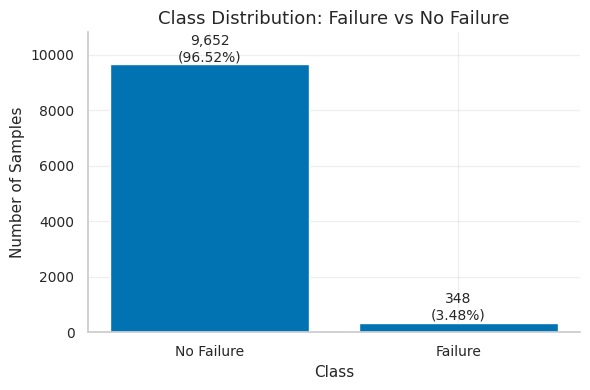

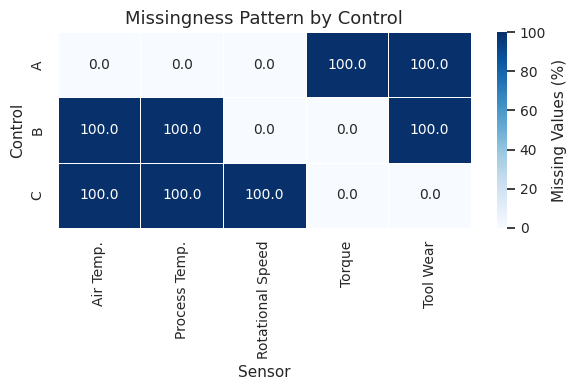

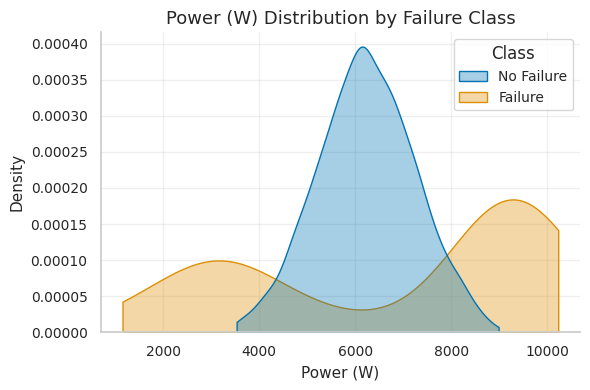

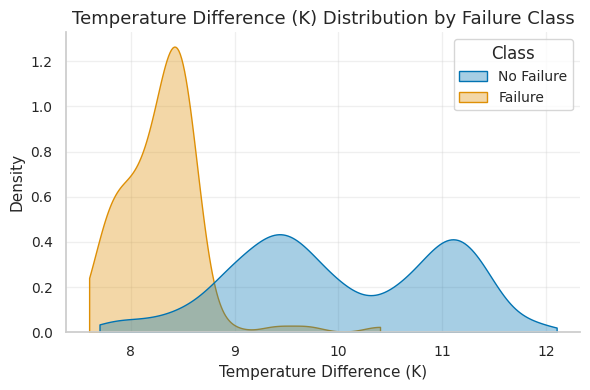

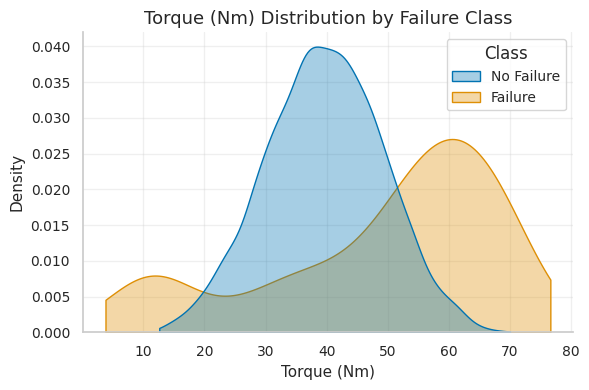

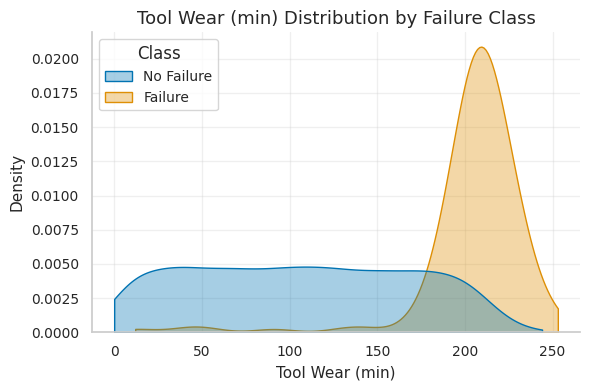

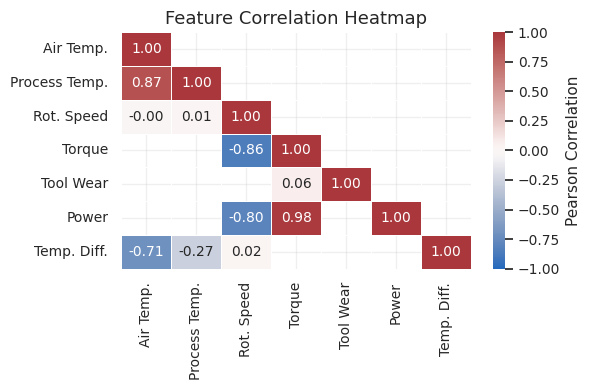

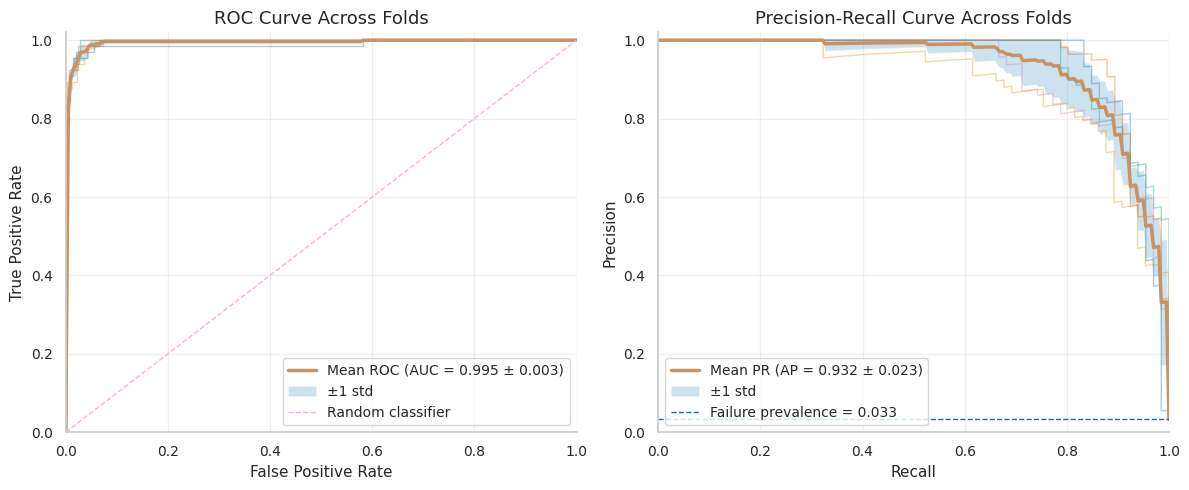

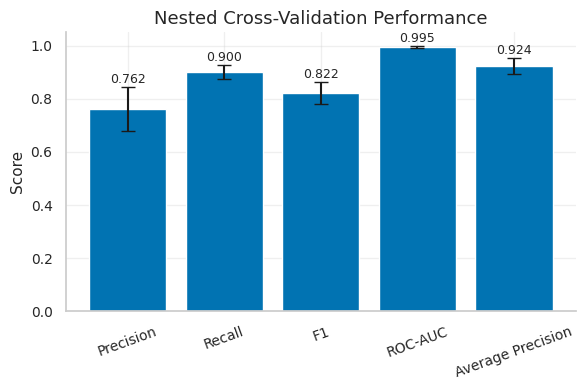

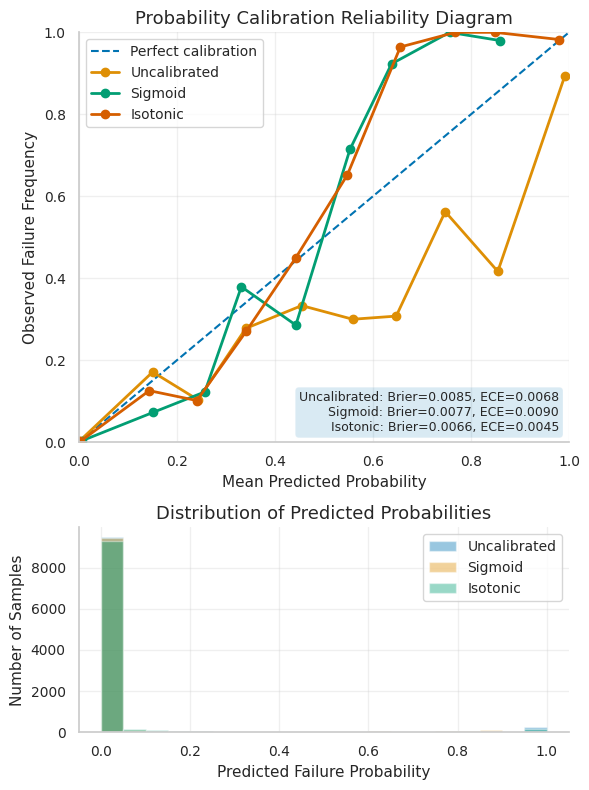

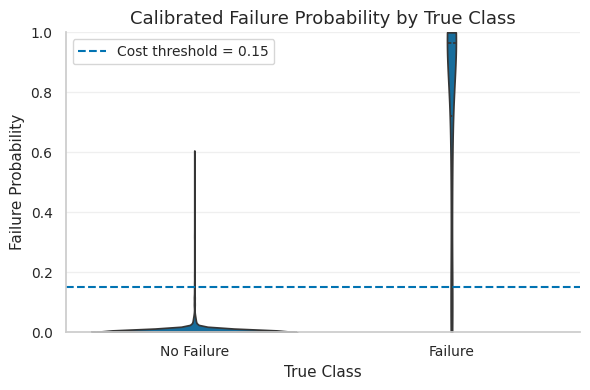

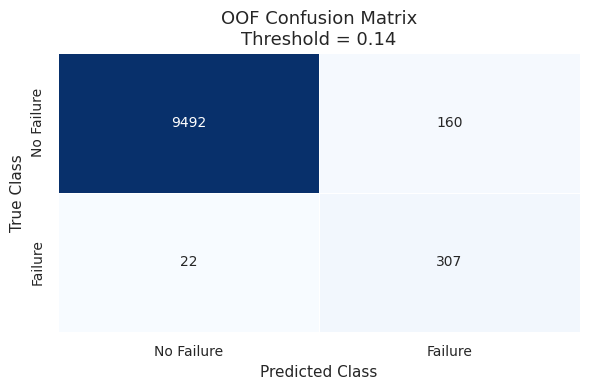

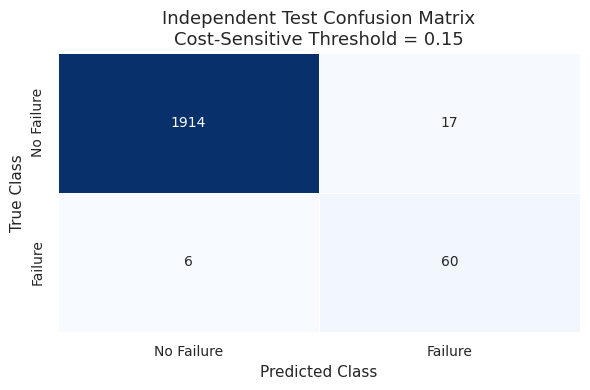

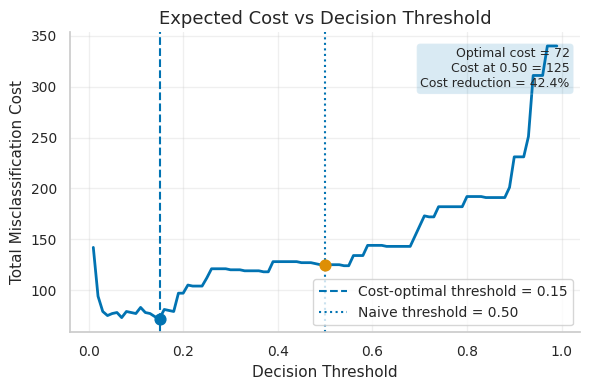

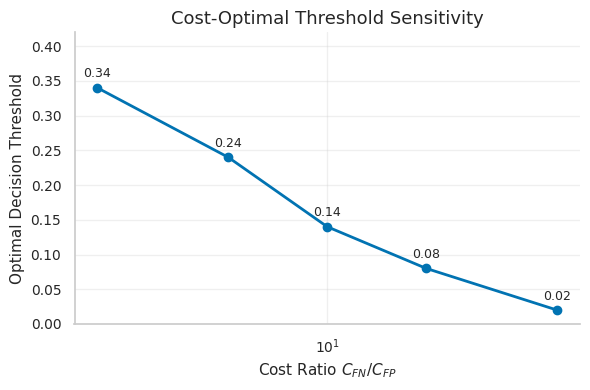

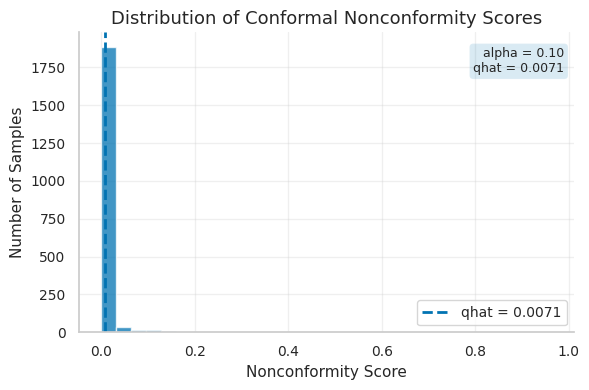

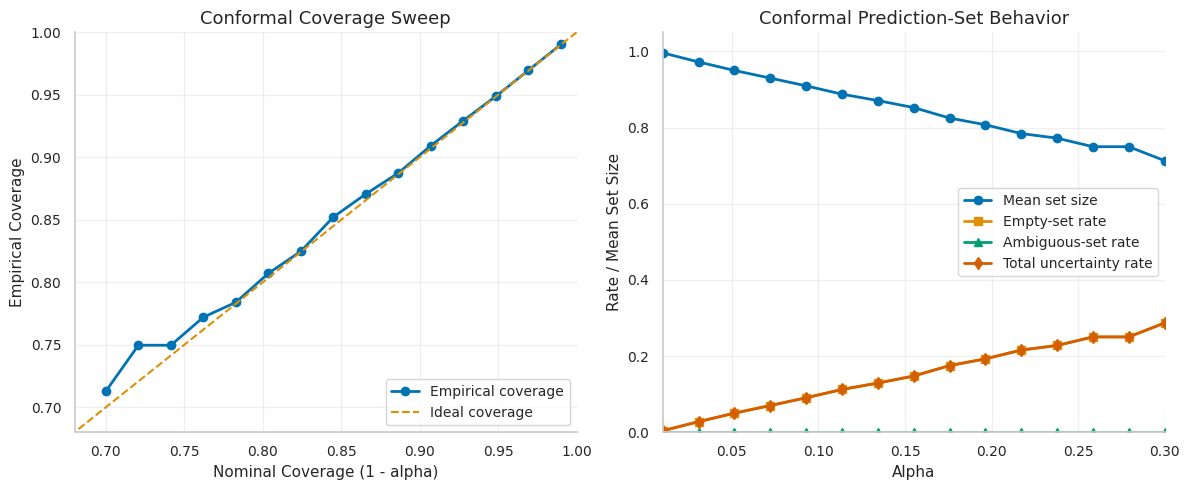

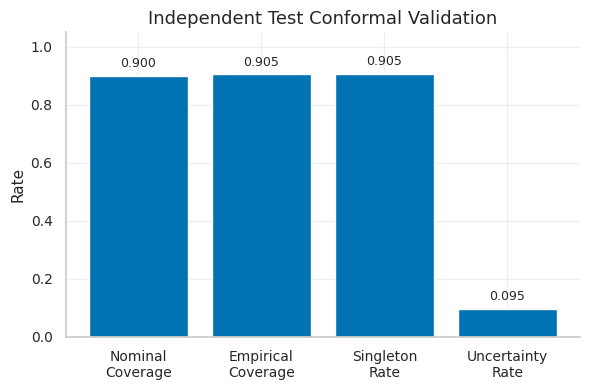

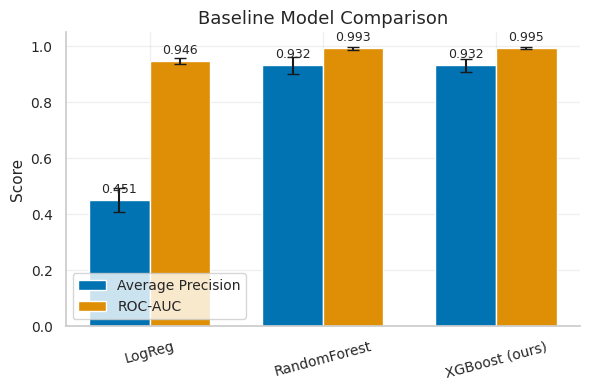


ALL FIGURES GENERATED SUCCESSFULLY
Saved in: /content/figures
Formats: PNG @ 300 dpi | PDF | SVG


In [90]:
# ============================================================================
# 15. Execute and Render All Publication-Grade Figures
# ============================================================================

print("Generating all Agent 1 figures...\n")

# ----------------------------------------------------------------------------
# A. EDA
# ----------------------------------------------------------------------------

fig_eda_class_balance(df)
fig_missingness_by_control(df)
fig_feature_dist_by_class(df)
fig_correlation_heatmap(df)


# ----------------------------------------------------------------------------
# B. Model performance
# ----------------------------------------------------------------------------

fig_roc_pr_with_bands(
    fold_data=fold_data,
    failure_prevalence=y.mean()
)

fig_metric_bars(
    nested_res=nested_res
)


# ----------------------------------------------------------------------------
# C. Probability calibration
# ----------------------------------------------------------------------------

fig_reliability(
    y=y,
    p_uncal=p_uncal,
    p_sigmoid=p_sigmoid,
    p_isotonic=p_isotonic
)

fig_prob_distribution(
    y=y_test_cost,
    p_cal=p_test_cost,
    threshold=t_star_split
)


# ----------------------------------------------------------------------------
# D. Confusion matrices
# ----------------------------------------------------------------------------

# OOF / model-development confusion matrix
fig_confusion_at_threshold(
    y=y,
    p_cal=p_isotonic,
    threshold=t_star
)

# Final independent-test confusion matrix
fig_confusion_independent_test(
    y_test=y_test_cost,
    p_test=p_test_cost,
    threshold=t_star_split
)


# ----------------------------------------------------------------------------
# E. Cost-sensitive decision
# ----------------------------------------------------------------------------

# Final cost curve — threshold selected on calibration subset
fig_cost_curve(
    ts=ts_split,
    costs=costs_split,
    threshold=t_star_split
)

# Cost sensitivity — exploratory OOF robustness analysis
fig_cost_sensitivity(
    sens_dict=sens
)


# ----------------------------------------------------------------------------
# F. Conformal uncertainty
# ----------------------------------------------------------------------------

# Proper split-conformal calibration scores
p_conf_fig = split_conf_results['p_conf']
y_conf_fig = split_conf_results['y_conf'].to_numpy()

conf_scores_fig = 1 - np.column_stack([
    1 - p_conf_fig,
    p_conf_fig
])[np.arange(len(y_conf_fig)), y_conf_fig]

fig_conformal_scores(
    scores=conf_scores_fig,
    qhat=qhat_split,
    alpha=split_conf_results['alpha']
)

# Exploratory conformal sweep
fig_conformal_coverage(
    alphas=alphas,
    cov=cov,
    size=size,
    empty=empty,
    ambiguous=ambiguous,
    uncertain=uncertain
)

# Final independent-test conformal validation
fig_split_conformal_validation(
    nominal_coverage=1 - split_conf_results['alpha'],
    empirical_coverage=split_conf_results['coverage'],
    singleton_rate=split_conf_results['singleton_rate'],
    uncertainty_rate=split_conf_results['uncertain_rate']
)
# ----------------------------------------------------------------------------
# G. Baseline comparison
# ----------------------------------------------------------------------------

fig_baseline_comparison(
    results=baseline_results
)


print("\n" + "=" * 70)
print("ALL FIGURES GENERATED SUCCESSFULLY")
print(f"Saved in: {FIG_DIR}")
print("Formats: PNG @ 300 dpi | PDF | SVG")
print("=" * 70)

In [91]:
# ---------------------------------------------------------------------------
# 16 Save Validated Agent 1 Package Function Definition
# ----------------------------------------------------------------------------

def save_validated_agent1_package(
    fitted_model,
    qhat,
    threshold,
    best,
    spw,
    out_dir,
    alpha=0.10,
    calibration_method='isotonic',
    c_fn=10.0,
    c_fp=1.0
):
    """
    Αποθηκεύει το ήδη fitted και validated Agent 1 model.

    ΣΗΜΑΝΤΙΚΟ:
    Δεν κάνει νέο fit.

    Το ίδιο fitted model είναι αυτό πάνω στο οποίο
    υπολογίστηκαν:
    - το conformal qhat
    - το cost-sensitive threshold
    - τα independent test metrics
    """

    os.makedirs(out_dir, exist_ok=True)

    package = {
        'model': fitted_model,

        'raw_features': [
            'Type'
        ] + RAW_SENSORS,

        'type_map': TYPE_MAP,

        'best_params': best,

        'scale_pos_weight': spw,

        'calibration_method': calibration_method,

        'conformal_qhat': float(qhat),

        'conformal_alpha': float(alpha),

        'cost_threshold': float(threshold),

        'cost_ratio': {
            'C_FN': float(c_fn),
            'C_FP': float(c_fp)
        },

        'validation_info': {
            'protocol': 'train / conformal-calibration / independent-test',

            'empirical_coverage': float(
                split_conf_results['coverage']
            ),

            'uncertainty_rate': float(
                split_conf_results['uncertain_rate']
            ),

            'threshold_precision': float(
                precision_test
            ),

            'threshold_recall': float(
                recall_test
            ),

            'threshold_f1': float(
                f1_test
            ),

            'threshold_test_cost': int(
                test_cost
            )
        }
    }

    save_path = os.path.join(
        out_dir,
        'agent1_validated_package.pkl'
    )

    joblib.dump(
        package,
        save_path
    )

    print(
        f"Saved validated Agent 1 package -> {save_path}"
    )

In [92]:
# ----------------------------------------------------------------------------
# 17. Agent 1 Inference Class Definition (Agent1FailureDetector)
# ----------------------------------------------------------------------------

class Agent1FailureDetector:
    """
    Agent 1 — Binary Failure Detection

    Input:
        raw machine/sensor measurements

    Output:
        - calibrated failure probability
        - cost-sensitive binary decision
        - conformal prediction set
        - uncertainty flag
    """

    def __init__(self, package_path):

        # ---------------------------------------------------------
        # Load saved Agent 1 package
        # ---------------------------------------------------------
        package = joblib.load(package_path)

        self.model = package['model']
        self.raw_features = package['raw_features']
        self.type_map = package['type_map']
        self.best_params = package['best_params']
        self.scale_pos_weight = package['scale_pos_weight']
        self.calibration_method = package['calibration_method']
        self.qhat = package['conformal_qhat']
        self.alpha = package['conformal_alpha']
        self.threshold = package['cost_threshold']
        self.cost_ratio = package['cost_ratio']


    def predict(
        self,
        machine_type,
        air_temperature,
        process_temperature,
        rotational_speed,
        torque,
        tool_wear
    ):
        """
        Κάνει πρόβλεψη για μία νέα παρατήρηση.

        """

        # ---------------------------------------------------------
        # 1. Machine Type encoding
        # ---------------------------------------------------------
        if isinstance(machine_type, str):

            if machine_type not in self.type_map:
                raise ValueError(
                    f"Unknown machine type: {machine_type}. "
                    f"Expected one of {list(self.type_map.keys())}."
                )

            machine_type_encoded = self.type_map[machine_type]

        else:
            machine_type_encoded = machine_type


        # ---------------------------------------------------------
        # 2. Δημιουργία raw input DataFrame
        # ---------------------------------------------------------
        X_new = pd.DataFrame([{
            'Type': machine_type_encoded,
            'Air_temperature_K': air_temperature,
            'Process_temperature_K': process_temperature,
            'Rotational_speed_rpm': rotational_speed,
            'Torque_Nm': torque,
            'Tool_wear_min': tool_wear
        }])


        # ---------------------------------------------------------
        # 3. Calibrated failure probability
        # ---------------------------------------------------------
        failure_probability = float(
            self.model.predict_proba(X_new)[0, 1]
        )


        # ---------------------------------------------------------
        # 4. Cost-sensitive binary decision
        # ---------------------------------------------------------
        decision = int(
            failure_probability >= self.threshold
        )

        prediction = (
            'FAILURE'
            if decision == 1
            else 'NO FAILURE'
        )


        # ---------------------------------------------------------
        # 5. Conformal prediction set
        # ---------------------------------------------------------
        class_probabilities = np.array([
            1.0 - failure_probability,
            failure_probability
        ])

        nonconformity = (
            1.0 - class_probabilities
        )

        included_classes = (
            nonconformity <= self.qhat
        )


        prediction_set = []

        if included_classes[0]:
            prediction_set.append(
                'NO FAILURE'
            )

        if included_classes[1]:
            prediction_set.append(
                'FAILURE'
            )


        # ---------------------------------------------------------
        # 6. Uncertainty
        # ---------------------------------------------------------
        uncertain = (
            len(prediction_set) != 1
        )

        if len(prediction_set) == 1:
            uncertainty_state = 'SINGLETON'
        elif len(prediction_set) == 0:
            uncertainty_state = 'EMPTY_SET'
        else:
            uncertainty_state = 'AMBIGUOUS_SET'

        # ---------------------------------------------------------
        # 7. Final Agent 1 output dictionary
        # ---------------------------------------------------------

        result = {
            'prediction': prediction,
            'failure_probability': round(failure_probability, 4),
            'decision': decision,
            'cost_threshold': round(self.threshold, 4),
            'prediction_set': prediction_set,
            'uncertain': uncertain,
            'uncertainty_state': uncertainty_state,
            'conformal_alpha': self.alpha,
            'conformal_qhat': round(self.qhat, 6),
            'calibration_method': self.calibration_method
        }

        return result

In [93]:
# ----------------------------------------------------------------------------
# 18. Execute Package Save and Load Validation Test
# ----------------------------------------------------------------------------

save_validated_agent1_package(
    fitted_model=model_split,
    qhat=qhat_split,
    threshold=t_star_split,
    best=best,
    spw=split_conf_results['scale_pos_weight_train'],
    out_dir='/content/agent1_validated_package',
    alpha=0.10,
    calibration_method='isotonic',
    c_fn=10.0,
    c_fp=1.0
)

# 2. Επιβεβαίωση φόρτωσης μέσω της κλάσης
validated_agent1 = Agent1FailureDetector(
    '/content/agent1_validated_package/agent1_validated_package.pkl'
)

print("Validated Agent 1 loaded successfully from disk.")

Saved validated Agent 1 package -> /content/agent1_validated_package/agent1_validated_package.pkl
Validated Agent 1 loaded successfully from disk.


In [94]:
# ----------------------------------------------------------------------------
# 19. RNF Stress Test (Robustness Check on Excluded Random Failures)
# ----------------------------------------------------------------------------

rnf_df = df[
    df['Diagnostic'] == 'Random Failures'
].copy()

rnf_results = []

for idx, row in rnf_df.iterrows():
    # Πρόβλεψη για τα δείγματα Random Failures που εξαιρέθηκαν από το training
    result = validated_agent1.predict(
        machine_type=int(row['Type']),
        air_temperature=row['Air_temperature_K'],
        process_temperature=row['Process_temperature_K'],
        rotational_speed=row['Rotational_speed_rpm'],
        torque=row['Torque_Nm'],
        tool_wear=row['Tool_wear_min']
    )

    rnf_results.append({
        'dataset_index': idx,
        'failure_probability': result['failure_probability'],
        'decision': result['decision'],
        'prediction': result['prediction'],
        'uncertain': result['uncertain'],
        'uncertainty_state': result['uncertainty_state']
    })

rnf_results = pd.DataFrame(rnf_results)

display(rnf_results)

# RNF stress-test summary
print("=== Random Failure Stress Test Summary ===")
print(f"Number of RNF samples: {len(rnf_results)}")
print(f"Mean failure probability:   {rnf_results['failure_probability'].mean():.4f}")
print(f"Median failure probability: {rnf_results['failure_probability'].median():.4f}")
print(f"RNF samples classified as FAILURE: {rnf_results['decision'].sum()} / {len(rnf_results)}")
print(f"RNF detection rate:         {rnf_results['decision'].mean():.4f}")
print(f"RNF uncertainty rate:       {rnf_results['uncertain'].mean():.4f}")

display(rnf_results.head())

,dataset_index,failure_probability,decision,prediction,uncertain,uncertainty_state
0,1223,0.0000,0,NO FAILURE,False,SINGLETON
1,1304,0.0000,0,NO FAILURE,False,SINGLETON
2,1750,0.0000,0,NO FAILURE,False,SINGLETON
3,2073,0.0006,0,NO FAILURE,False,SINGLETON
4,2559,0.0000,0,NO FAILURE,False,SINGLETON
5,3063,0.0000,0,NO FAILURE,False,SINGLETON
6,3454,0.0000,0,NO FAILURE,False,SINGLETON
7,3611,0.1132,0,NO FAILURE,True,EMPTY_SET
8,5470,0.0375,0,NO FAILURE,True,EMPTY_SET
9,5489,0.0006,0,NO FAILURE,False,SINGLETON


=== Random Failure Stress Test Summary ===
Number of RNF samples: 19
Mean failure probability:   0.0090
Median failure probability: 0.0000
RNF samples classified as FAILURE: 0 / 19
RNF detection rate:         0.0000
RNF uncertainty rate:       0.2105


,dataset_index,failure_probability,decision,prediction,uncertain,uncertainty_state
0,1223,0.0000,0,NO FAILURE,False,SINGLETON
1,1304,0.0000,0,NO FAILURE,False,SINGLETON
2,1750,0.0000,0,NO FAILURE,False,SINGLETON
3,2073,0.0006,0,NO FAILURE,False,SINGLETON
4,2559,0.0000,0,NO FAILURE,False,SINGLETON


In [95]:
# ============================================================================
# 20. Final Validated Results Summary Table
# ============================================================================

final_summary = pd.DataFrame({
    'Metric': [
        'Nested-CV Precision',
        'Nested-CV Recall',
        'Nested-CV F1',
        'Nested-CV ROC-AUC',
        'Nested-CV Average Precision',
        'Calibration Method',
        'Cost Ratio C_FN:C_FP',
        'Cost-Optimal Threshold',
        'Independent-Test Precision',
        'Independent-Test Recall',
        'Independent-Test F1',
        'Independent-Test Cost',
        'Conformal Alpha',
        'Conformal qhat',
        'Nominal Coverage',
        'Empirical Test Coverage',
        'Test Singleton Rate',
        'Test Uncertainty Rate',
        'RNF Detection Rate',
        'RNF Uncertainty Rate'
    ],
    'Value': [
        f"{nested_res['test_precision'].mean():.4f} ± {nested_res['test_precision'].std():.4f}",
        f"{nested_res['test_recall'].mean():.4f} ± {nested_res['test_recall'].std():.4f}",
        f"{nested_res['test_f1'].mean():.4f} ± {nested_res['test_f1'].std():.4f}",
        f"{nested_res['test_roc_auc'].mean():.4f} ± {nested_res['test_roc_auc'].std():.4f}",
        f"{nested_res['test_average_precision'].mean():.4f} ± {nested_res['test_average_precision'].std():.4f}",
        'Isotonic',
        '10:1',
        f"{t_star_split:.2f}",
        f"{precision_test:.4f}",
        f"{recall_test:.4f}",
        f"{f1_test:.4f}",
        f"{test_cost}",
        f"{split_conf_results['alpha']:.2f}",
        f"{qhat_split:.6f}",
        f"{1 - split_conf_results['alpha']:.4f}",
        f"{split_conf_results['coverage']:.4f}",
        f"{split_conf_results['singleton_rate']:.4f}",
        f"{split_conf_results['uncertain_rate']:.4f}",
        f"{rnf_results['decision'].mean():.4f}",
        f"{rnf_results['uncertain'].mean():.4f}"
    ]
})

print("=== FINAL AGENT 1 VALIDATED PERFORMANCE SUMMARY ===")
display(final_summary)

=== FINAL AGENT 1 VALIDATED PERFORMANCE SUMMARY ===


,Metric,Value
0,Nested-CV Precision,0.7617 ± 0.0822
1,Nested-CV Recall,0.8996 ± 0.0267
2,Nested-CV F1,0.8220 ± 0.0413
3,Nested-CV ROC-AUC,0.9947 ± 0.0032
4,Nested-CV Average Precision,0.9242 ± 0.0297
5,Calibration Method,Isotonic
6,Cost Ratio C_FN:C_FP,10:1
7,Cost-Optimal Threshold,0.15
8,Independent-Test Precision,0.7792
9,Independent-Test Recall,0.9091


In [96]:
# ============================================================================
# 21. Main Execution Workflow Block for Agent 1 Pipeline
# ============================================================================

if __name__ == '__main__':

    print("=== AGENT 1 — Binary Failure Detection ===")

    # 1. Data
    df = load_pmdi('/content/AI4I-PMDI.csv')
    X, y = define_target(df)
    spw = (y == 0).sum() / (y == 1).sum()

    # 2. Nested CV
    nested_res = nested_cv_evaluate(X, y, spw)

    # 3. Hyperparameter tuning
    final_search = GridSearchCV(
        build_pipeline(
            XGBClassifier(
                scale_pos_weight=spw,
                eval_metric='logloss',
                random_state=RANDOM_STATE
            ),
            use_smote=False
        ),
        PARAM_GRID,
        scoring='average_precision',
        cv=StratifiedKFold(
            5,
            shuffle=True,
            random_state=RANDOM_STATE
        ),
        n_jobs=-1
    )

    final_search.fit(X, y)

    best = {
        k.replace('clf__', ''): v
        for k, v in final_search.best_params_.items()
    }

    # 4. ROC / PR
    pipe = build_pipeline(
        XGBClassifier(
            scale_pos_weight=spw,
            eval_metric='logloss',
            random_state=RANDOM_STATE,
            **best
        ),
        use_smote=False
    )

    fold_data = collect_fold_curves(pipe, X, y)

    # 5. Calibration
    p_uncal, p_sigmoid, p_isotonic, calibration_results = oof_probs(
        X, y, best, spw
    )

    p_cal = p_isotonic
    CALIBRATION_METHOD = 'isotonic'

    # 6. Exploratory OOF cost + conformal
    ts, costs, t_star = cost_curve(
        y.values,
        p_cal,
        c_fn=10,
        c_fp=1
    )

    qhat_oof, cscores = conformal_qhat(
        y,
        p_cal,
        alpha=0.10
    )

    alphas, cov, size, empty, ambiguous, uncertain = conformal_sweep(
        y,
        p_cal
    )

    # 7. Proper split-conformal validation
    split_conf_results = split_conformal_evaluate(
        X,
        y,
        best,
        spw,
        alpha=0.10,
        test_size=0.20,
        calibration_size=0.20
    )

    qhat_split = split_conf_results['qhat']
    model_split = split_conf_results['model']

    X_conf_cost = split_conf_results['X_conf']
    y_conf_cost = split_conf_results['y_conf']

    X_test_cost = split_conf_results['X_test']
    y_test_cost = split_conf_results['y_test']

    # 8. Final cost threshold
    p_conf_cost = model_split.predict_proba(X_conf_cost)[:, 1]

    ts_split, costs_split, t_star_split = cost_curve(
        y_conf_cost.values,
        p_conf_cost,
        c_fn=10,
        c_fp=1
    )

    p_test_cost = model_split.predict_proba(X_test_cost)[:, 1]

    y_pred_test = (p_test_cost >= t_star_split).astype(int)

    precision_test = precision_score(y_test_cost, y_pred_test)
    recall_test = recall_score(y_test_cost, y_pred_test)
    f1_test = f1_score(y_test_cost, y_pred_test)

    tn, fp, fn, tp = confusion_matrix(
        y_test_cost,
        y_pred_test
    ).ravel()

    test_cost = 10 * fn + fp

    sens = cost_sensitivity(
        y_conf_cost.values,
        p_conf_cost
    )

    # 9. Baselines
    baseline_results = baseline_comparison(
        X,
        y,
        spw,
        best
    )

    # 10. Save validated Agent 1
    save_validated_agent1_package(
        fitted_model=model_split,
        qhat=qhat_split,
        threshold=t_star_split,
        best=best,
        spw=split_conf_results['scale_pos_weight_train'],
        out_dir='/content/agent1_validated_package',
        alpha=0.10,
        calibration_method='isotonic',
        c_fn=10.0,
        c_fp=1.0
    )

    validated_agent1 = Agent1FailureDetector(
        '/content/agent1_validated_package/agent1_validated_package.pkl'
    )

    print("\n=== FINAL AGENT 1 RESULTS ===")
    print(f"Best params: {best}")
    print(f"Threshold: {t_star_split:.2f}")
    print(f"Precision: {precision_test:.4f}")
    print(f"Recall: {recall_test:.4f}")
    print(f"F1: {f1_test:.4f}")
    print(f"Test cost: {test_cost}")
    print(f"Conformal qhat: {qhat_split:.6f}")
    print(f"Coverage: {split_conf_results['coverage']:.4f}")
    print(f"Uncertainty: {split_conf_results['uncertain_rate']:.4f}")
    print("\nAgent 1 completed successfully.")

=== AGENT 1 — Binary Failure Detection ===


/usr/local/lib/python3.13/dist-packages/joblib/externals/loky/process_executor.py:787: UserWarning: A worker stopped while some jobs were given to the executor. This can be caused by a too short worker timeout or by a memory leak.
  warnings.warn(


=== Nested-CV (τίμια γενίκευση) ===
  precision         : 0.7617 ± 0.0822
  recall            : 0.8996 ± 0.0267
  f1                : 0.8220 ± 0.0413
  roc_auc           : 0.9947 ± 0.0032
  average_precision : 0.9242 ± 0.0297


/usr/local/lib/python3.13/dist-packages/joblib/externals/loky/process_executor.py:787: UserWarning: A worker stopped while some jobs were given to the executor. This can be caused by a too short worker timeout or by a memory leak.
  warnings.warn(


=== Calibration comparison ===


,Method,Brier,ECE
0,Uncalibrated,0.0085,0.0068
1,Sigmoid,0.0077,0.0090
2,Isotonic,0.0066,0.0045


Cost-optimal threshold (C_FN=10, C_FP=1): 0.14
Conformal qhat (alpha=0.1): 0.0096
=== Split sizes ===
Training set:              5988
Conformal calibration set: 1996
Independent test set:      1997

Split-conformal qhat (alpha=0.1): 0.007143

=== Independent test conformal results ===
Nominal coverage:   0.9000
Empirical coverage: 0.9049
Empty-set rate:     0.0946
Singleton rate:     0.9054
Ambiguous-set rate: 0.0000
Uncertainty rate:   0.0946
Cost-optimal threshold (C_FN=10, C_FP=1): 0.15
Cost-optimal threshold (C_FN=2, C_FP=1.0): 0.54
Cost-optimal threshold (C_FN=5, C_FP=1.0): 0.15
Cost-optimal threshold (C_FN=10, C_FP=1.0): 0.15
Cost-optimal threshold (C_FN=20, C_FP=1.0): 0.03
Cost-optimal threshold (C_FN=50, C_FP=1.0): 0.03
LogReg             | Precision=0.179 ± 0.011 | Recall=0.891 ± 0.032 | F1=0.298 ± 0.017 | AP=0.451 ± 0.043 | ROC-AUC=0.946 ± 0.010
RandomForest       | Precision=0.947 ± 0.052 | Recall=0.754 ± 0.048 | F1=0.839 ± 0.047 | AP=0.932 ± 0.031 | ROC-AUC=0.993 ± 0.005
XG

In [97]:
# ============================================================================
# 22. Create Deployment Folder & Copy Validated Model Artifact.
# ============================================================================

import os
import shutil

PACKAGE_DIR = '/content/agent1_package'

os.makedirs(PACKAGE_DIR, exist_ok=True)

# Copy validated trained artifact
shutil.copy(
    '/content/agent1_validated_package/agent1_validated_package.pkl',
    f'{PACKAGE_DIR}/agent1_validated_package.pkl'
)

print("Agent 1 deployment folder created.")
print(os.listdir(PACKAGE_DIR))

Agent 1 deployment folder created.
['predict.py', '__pycache__', 'agent1_validated_package.pkl', 'requirements.txt']


In [98]:
# ---------------------------------------------------------------
# 22.1 Write Standalone Inference Script (predict.py) for Production Deployment
# --------------------------------------------------------------

%%writefile /content/agent1_package/predict.py

import os
import sys
import joblib
import numpy as np
import pandas as pd

from sklearn import set_config
from sklearn.calibration import CalibratedClassifierCV
from sklearn.preprocessing import FunctionTransformer
from sklearn.impute import KNNImputer
from imblearn.pipeline import Pipeline
from xgboost import XGBClassifier


# IMPORTANT:
# Same sklearn output configuration used during training
set_config(transform_output="pandas")


# ============================================================================
# Feature Engineering (Πρέπει να είναι απολύτως ταυτόσημο με το training)
# ============================================================================

def engineer_features(X):
    X = X.copy()

    # Υπολογισμός ισχύος σε Watt
    X['Power_W'] = (
        X['Torque_Nm']
        * (
            X['Rotational_speed_rpm']
            * 2 * np.pi / 60
        )
    )

    # Υπολογισμός διαφοράς θερμοκρασίας σε Kelvin
    X['Temp_diff_K'] = (
        X['Process_temperature_K']
        - X['Air_temperature_K']
    )

    return X


# Ορισμός στο __main__ ώστε να επιτρέπεται το σωστό deserialization του fitted pipeline
import __main__
__main__.engineer_features = engineer_features


# ============================================================================
# Paths
# ============================================================================

if '__file__' in globals():
    SCRIPT_DIR = os.path.dirname(
        os.path.abspath(__file__)
    )
else:
    # When code is copied directly into a Colab/Jupyter cell
    SCRIPT_DIR = os.getcwd()

MODEL_PATH = os.path.join(
    SCRIPT_DIR,
    'agent1_validated_package.pkl'
)

# Extra fallback for Colab
if not os.path.exists(MODEL_PATH):

    colab_path = (
        '/content/agent1_package/'
        'agent1_validated_package.pkl'
    )

    if os.path.exists(colab_path):
        MODEL_PATH = colab_path

# ============================================================================
# Agent 1
# ============================================================================

class Agent1FailureDetector:
    """
    Agent 1 — Standalone Binary Failure Detection Inference Engine.
    Φορτώνει το επικυρωμένο πακέτο και παρέχει calibrated προβλέψεις,
    cost-sensitive αποφάσεις και conformal prediction sets.
    """
    def __init__(self, package_path=MODEL_PATH):
        package = joblib.load(package_path)

        self.model = package['model']
        self.type_map = package['type_map']
        self.threshold = package['cost_threshold']
        self.qhat = package['conformal_qhat']
        self.alpha = package['conformal_alpha']
        self.calibration_method = package['calibration_method']


    def predict(self, machine_data):

        data = machine_data.copy()

        # 1. Κωδικοποίηση τύπου μηχανής (Type mapping)
        machine_type = data['Type']

        if isinstance(machine_type, str):

            machine_type = machine_type.upper()

            if machine_type not in self.type_map:
                raise ValueError(
                    f"Unknown Type: {machine_type}. "
                    f"Expected {list(self.type_map.keys())}"
                )

            machine_type = self.type_map[
                machine_type
            ]

        else:
            machine_type = int(
                machine_type
            )


        # 2. Δημιουργία τυποποιημένου DataFrame εισόδου
        X_new = pd.DataFrame([{
            'Type': machine_type,
            'Air_temperature_K': data.get('Air_temperature_K', np.nan),
            'Process_temperature_K': data.get('Process_temperature_K', np.nan),
            'Rotational_speed_rpm': data.get('Rotational_speed_rpm', np.nan),
            'Torque_Nm': data.get('Torque_Nm', np.nan),
            'Tool_wear_min': data.get('Tool_wear_min', np.nan)
        }])

        # 3. Υπολογισμός calibrated πιθανότητας αποτυχίας
        failure_probability = float(
            self.model.predict_proba(X_new)[0, 1]
        )

        # 4. Cost-sensitive δυαδική απόφαση βάσει του βέλτιστου κατωφλίου (threshold)
        failure_detected = bool(
            failure_probability >= self.threshold
        )

        # 5. Κατασκευή conformal prediction set και έλεγχος αβεβαιότητας
        class_probs = np.array([
            1.0 - failure_probability,
            failure_probability
        ])

        included = (
            1.0 - class_probs
            <= self.qhat
        )

        prediction_set = []

        if included[0]:
            prediction_set.append(
                'NO FAILURE'
            )

        if included[1]:
            prediction_set.append(
                'FAILURE'
            )


        uncertain = (
            len(prediction_set) != 1
        )

        if len(prediction_set) == 1:
            uncertainty_state = 'SINGLETON'

        elif len(prediction_set) == 0:
            uncertainty_state = 'EMPTY_SET'

        else:
            uncertainty_state = 'AMBIGUOUS_SET'


       # 6. Δημιουργία δομημένου payload για διασύνδεση με τον Agent 2 (εφόσον ανιχνευθεί σφάλμα)
        agent2_payload = None
        if failure_detected:
            agent2_payload = {
                'Type': machine_type,
                'Air_temperature_K': data.get('Air_temperature_K', np.nan),
                'Process_temperature_K': data.get('Process_temperature_K', np.nan),
                'Rotational_speed_rpm': data.get('Rotational_speed_rpm', np.nan),
                'Torque_Nm': data.get('Torque_Nm', np.nan),
                'Tool_wear_min': data.get('Tool_wear_min', np.nan),
                'agent1_failure_probability': round(failure_probability, 6),
                'agent1_uncertain': uncertain,
                'agent1_uncertainty_state': uncertainty_state,
                'agent1_prediction_set': prediction_set
            }

        # 7. Τελικό λεξικό αποτελεσμάτων παραγωγής
        return {
            'prediction': 'FAILURE' if failure_detected else 'NO FAILURE',
            'failure_probability': round(failure_probability, 6),
            'failure_detected': failure_detected,
            'threshold': round(self.threshold, 6),
            'prediction_set': prediction_set,
            'uncertain': uncertain,
            'uncertainty_state': uncertainty_state,
            'conformal_alpha': self.alpha,
            'conformal_qhat': round(self.qhat, 6),
            'calibration_method': self.calibration_method,
            'send_to_agent2': failure_detected,
            'agent2_payload': agent2_payload
        }


# ============================================================================
# Public interface
# ============================================================================

_agent = None


def predict_failure(machine_data):

    """
    Δημόσια συνάρτηση διασύνδεσης για εύκολη κλήση της πρόβλεψης
    χωρίς την ανάγκη manual χειρισμού της κλάσης.
    """
    global _agent

    if _agent is None:
        _agent = Agent1FailureDetector()

    return _agent.predict(
        machine_data
    )

# Δοκιμή πρόβλεψης με τυπικά δεδομένα αισθητήρων μηχανής
result = predict_failure({
    'Type': 'M',
    'Air_temperature_K': 300.5,
    'Process_temperature_K': 311.2,
    'Rotational_speed_rpm': 1350,
    'Torque_Nm': 65.0,
    'Tool_wear_min': 200
})

print("Sample prediction result:")
print(result)

Overwriting /content/agent1_package/predict.py


In [99]:
# -----------------------------------------------------------------
# 22.2 Write Package Dependencies (requirements.txt) for Deployment
# -----------------------------------------------------------------

%%writefile /content/agent1_package/requirements.txt
numpy
pandas
scikit-learn
imbalanced-learn
xgboost
cloudpickle

Overwriting /content/agent1_package/requirements.txt


In [100]:
# -------------------------------------------------------------------
# 23. Import and Test Prediction Module
# ------------------------------------------------------------------

import sys

sys.path.insert(
    0,
    '/content/agent1_package'
)

# Αποφυγή caching παλαιότερων modules
if 'predict' in sys.modules:
    del sys.modules['predict']

from predict import predict_failure

print("predict.py imported successfully.")

# Δοκιμή πρόβλεψης με δείγμα εισόδου
result = predict_failure({
    'Type': 'M',
    'Air_temperature_K': 300.5,
    'Process_temperature_K': 311.2,
    'Rotational_speed_rpm': 1350,
    'Torque_Nm': 65.0,
    'Tool_wear_min': 200
})

print("\nSample prediction result:")
print(result)

Sample prediction result:
{'prediction': 'FAILURE', 'failure_probability': 0.886794, 'failure_detected': True, 'threshold': 0.15, 'prediction_set': [], 'uncertain': True, 'uncertainty_state': 'EMPTY_SET', 'conformal_alpha': 0.1, 'conformal_qhat': 0.007143, 'calibration_method': 'isotonic', 'send_to_agent2': True, 'agent2_payload': {'Type': 1, 'Air_temperature_K': 300.5, 'Process_temperature_K': 311.2, 'Rotational_speed_rpm': 1350, 'Torque_Nm': 65.0, 'Tool_wear_min': 200, 'agent1_failure_probability': 0.886794, 'agent1_uncertain': True, 'agent1_uncertainty_state': 'EMPTY_SET', 'agent1_prediction_set': []}}
predict.py imported successfully.

Sample prediction result:
{'prediction': 'FAILURE', 'failure_probability': 0.886794, 'failure_detected': True, 'threshold': 0.15, 'prediction_set': [], 'uncertain': True, 'uncertainty_state': 'EMPTY_SET', 'conformal_alpha': 0.1, 'conformal_qhat': 0.007143, 'calibration_method': 'isotonic', 'send_to_agent2': True, 'agent2_payload': {'Type': 1, 'Air_te

In [101]:
# -------------------------------------------------------------------
# 24. Compress Deployment Package & Trigger Download (.zip)
# ------------------------------------------------------------------

import shutil
from google.colab import files

# Συμπίεση του φακέλου παραγωγής σε αρχείο zip
shutil.make_archive(
    '/content/agent1_package',
    'zip',
    '/content/agent1_package'
)
print("Deployment package successfully archived to '/content/agent1_package.zip'")

# Αυτόματο κατέβασμα αρχείου
files.download(
    '/content/agent1_package.zip'
)

Deployment package successfully archived to '/content/agent1_package.zip'


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>